<div align="center" style="font-size: 3em; font-weight: bold;">Анализ цен на Мосбирже некоторых крупных компаний РФ</div>

<div align="center">
    <img src="MOEX.webp" alt="Логотип Московской биржи" width="50%">
    
</div>

<h2 style="font-size: 2.3em;">Цель исследования</h2>
<p style="font-size: 2em;">Анализ временных рядов акций MOEX и построение моделей прогнозирования.</p>

<h2 style="font-size: 1.8em;">Задачи исследования</h2>
<ul style="font-size: 1.6em;">
    <li>Оценка стационарности рядов</li>
    <li>Выбор оптимальных моделей (ARIMA, GARCH)</li>
    <li>Сравнение точности прогнозов</li>
    <li>Оценка рисков (волатильность)</li>
</ul>

<div align="left" style="font-size: 1.6em;">
    <h3> В ходе нашей работы мы проведём:</h3>
    <ul>
        <li> Сбор данных, их очистку и подготовку</li>
        <li> Разведочный анализ данных</li>
        <li> Подготовку данных к обучению моделей</li>
        <li> Прогнозирование направления движения цен</li>
        <li> Анализ волатильности цен на акции</li>
        <li> Формулирование выводов</li>
    </ul>
</div>

## Используемые пакеты при работе:

In [1]:
import requests
import pandas as pd
import numpy as np
import time
import statsmodels.api as sm
import pmdarima as pm
import pickle
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import SimpleExpSmoothing
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from datetime import datetime
from arch import  arch_model
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


### Код которым парсился датафрейм.Сохрним его в Markdown,чтобы не выполнять его каждый раз как прогоняем проект.

'''python

Словарь с названиями компаний

COMPANY_NAMES = {
    'SBER': 'Сбербанк',
    'VTBR': 'ВТБ',
    'GAZP': 'Газпром',
    'LKOH': 'Лукойл',
    'MTSS': 'МТС',
    'RTKM': 'Ростелеком',
    'MGNT': 'Магнит',
    'ROSN': 'Роснефть',
    'TATN': 'Татнефть',
    'YNDX': 'Яндекс',
    'AFKS': 'АФК Система',
    'NVTK': 'Новатэк',
    'CHMF': 'Северсталь',
    'NLMK': 'НЛМК',
    'MMK': 'ММК'
}

def get_moex_data(ticker, start_year, end_year, interval=24):
    """
    Собирает исторические данные с MOEX
    
    Parameters:
    ticker: str - тикер акции ('SBER', 'GAZP', 'LKOH' и т.д.)
    start_year: int - начальный год
    end_year: int - конечный год
    interval: int - таймфрейм (24 = дневные свечи)
    """
    
    all_data = []
    
    for year in range(start_year, end_year + 1):
        # Добавляем название компании в вывод
        company_name = COMPANY_NAMES.get(ticker, ticker)
        print(f"Собираем {ticker} ({company_name}) за {year} год...")
        
        url = f"http://iss.moex.com/iss/engines/stock/markets/shares/boards/tqbr/securities/{ticker}/candles.json"
        
        params = {
            'from': f'{year}-01-01',
            'till': f'{year}-12-31',
            'interval': interval
        }
        
        try:
            response = requests.get(url, params=params)
            
            # Проверяем, что запрос успешный
            if response.status_code != 200:
                print(f"  Ошибка: {response.status_code}")
                continue
            
            data = response.json()
            
            # Извлекаем данные
            candles = data['candles']['data']
            # columns теперь список строк, а не список словарей
            columns = data['candles']['columns']
            
            if candles:  # если данные есть
                df = pd.DataFrame(candles, columns=columns)
                df['year'] = year
                df['ticker'] = ticker  # Добавляем тикер
                df['company_name'] = COMPANY_NAMES.get(ticker, ticker)  # Добавляем название компании
                all_data.append(df)
                print(f"  Загружено {len(df)} свечей")
            else:
                print(f"  Нет данных за {year}")
            
            # Пауза чтобы не перегружать сервер
            time.sleep(1)
            
        except Exception as e:
            print(f"  Ошибка при загрузке: {e}")
            continue
    
    if not all_data:
        return pd.DataFrame()
    
    Объединяем все годы
    
    result = pd.concat(all_data, ignore_index=True)
    
    Преобразуем дату в datetime
    
    result['begin'] = pd.to_datetime(result['begin'])
    result.set_index('begin', inplace=True)
    
    Сортируем по дате
    
    result.sort_index(inplace=True)
    
    return result



Список акций (голубые фишки)

tickers = ['SBER', 'VTBR', 'GAZP', 'LKOH', 'MTSS', 'RTKM', 'MGNT']

all_stocks = {}

print("НАЧАЛО СБОРА ДАННЫХ")
print("="*60)
print("Компании для сбора:")
for ticker in tickers:
    print(f"  - {ticker}: {COMPANY_NAMES.get(ticker, ticker)}")
print("="*60)

for ticker in tickers:
    print(f"\n{'='*50}")
    print(f"Собираем {ticker} - {COMPANY_NAMES.get(ticker, ticker)}")
    print('='*50)
    
    df = get_moex_data(ticker, 2014, 2024, 24)
    
    if not df.empty:
        all_stocks[ticker] = df
        
        # Сохраняем отдельно для каждой акции с названием в имени файла
        company_name_clean = COMPANY_NAMES.get(ticker, ticker).replace(' ', '_')
        filename = f'{ticker}_{company_name_clean}_2014_2024.csv'
        df.to_csv(filename)
        print(f"\n✓ {COMPANY_NAMES.get(ticker, ticker)} ({ticker}): {len(df)} дней")
        print(f"  Сохранен в: {filename}")
    else:
        print(f"\n✗ Не удалось собрать данные для {COMPANY_NAMES.get(ticker, ticker)} ({ticker})")



if all_stocks:
    combined_list = []
    for ticker, df in all_stocks.items():
        df_copy = df.copy()
        # ticker и company_name уже есть в df, ничего добавлять не нужно
        combined_list.append(df_copy)
    
    combined_df = pd.concat(combined_list, ignore_index=False)
    combined_df.to_csv('C:/Users/Lenovo/Desktop/all_stocks_with_names_2014_2024.csv')
    

    
    print(f"\n Состав датасета:")
    for ticker, df in all_stocks.items():
        print(f"  - {COMPANY_NAMES.get(ticker, ticker)} ({ticker}): {len(df)} дней")
    
    print(f"\n Файлы сохранены:")
    print(f"  - По каждой компании: отдельные CSV файлы")
    print(f"  - Общий файл: all_stocks_with_names_2014_2024.csv")
    
    # Показываем пример данных
    print(f"\n Пример данных (первые 5 строк для Сбербанка):")
    if 'SBER' in all_stocks:
        print(all_stocks['SBER'][['ticker', 'company_name', 'close', 'volume']].head())
    
    print(stats_df.to_string(index=False))

    combined_df.to_csv('C:/Users/Lenovo/Desktop/MOEX.csv')

'''

# Загружаем собранные данные и начинаем с ними работу

In [2]:
df = pd.read_csv('C:/Users/Lenovo/IDE/SFDS/data/MOEX Analisys & ARIMA/MOEX.csv')
df['begin'] = pd.to_datetime(df['begin'])
df.set_index('begin', inplace=True)



Оставляем только цену при хакрытии торгов.Остальную информацию можно созранеить и использовать в дальнейшем

In [3]:
df_wide = df.pivot_table(index=df.index, columns='ticker', values='close', aggfunc='last')
df_wide

ticker,GAZP,LKOH,MGNT,MTSS,RTKM,SBER,VTBR
begin,,,,,,,
2014-01-06,NaN,1990.2,8956.9,315.02,110.29,98.91,242.30
2014-01-08,NaN,1959.1,9154.9,314.63,110.25,98.19,239.55
2014-01-09,NaN,1979.1,8990.5,312.04,110.65,98.00,240.60
2014-01-10,NaN,1991.6,8450.1,313.43,110.99,99.20,242.30
2014-01-13,NaN,2001.1,8258.5,317.08,111.92,100.25,244.60
...,...,...,...,...,...,...,...
2024-12-25,128.11,6987.5,5027.5,196.45,58.46,271.69,76.53
2024-12-26,126.89,7003.0,5174.0,196.00,59.27,269.56,75.74
2024-12-27,127.79,6990.5,5210.0,196.00,59.97,271.20,76.49


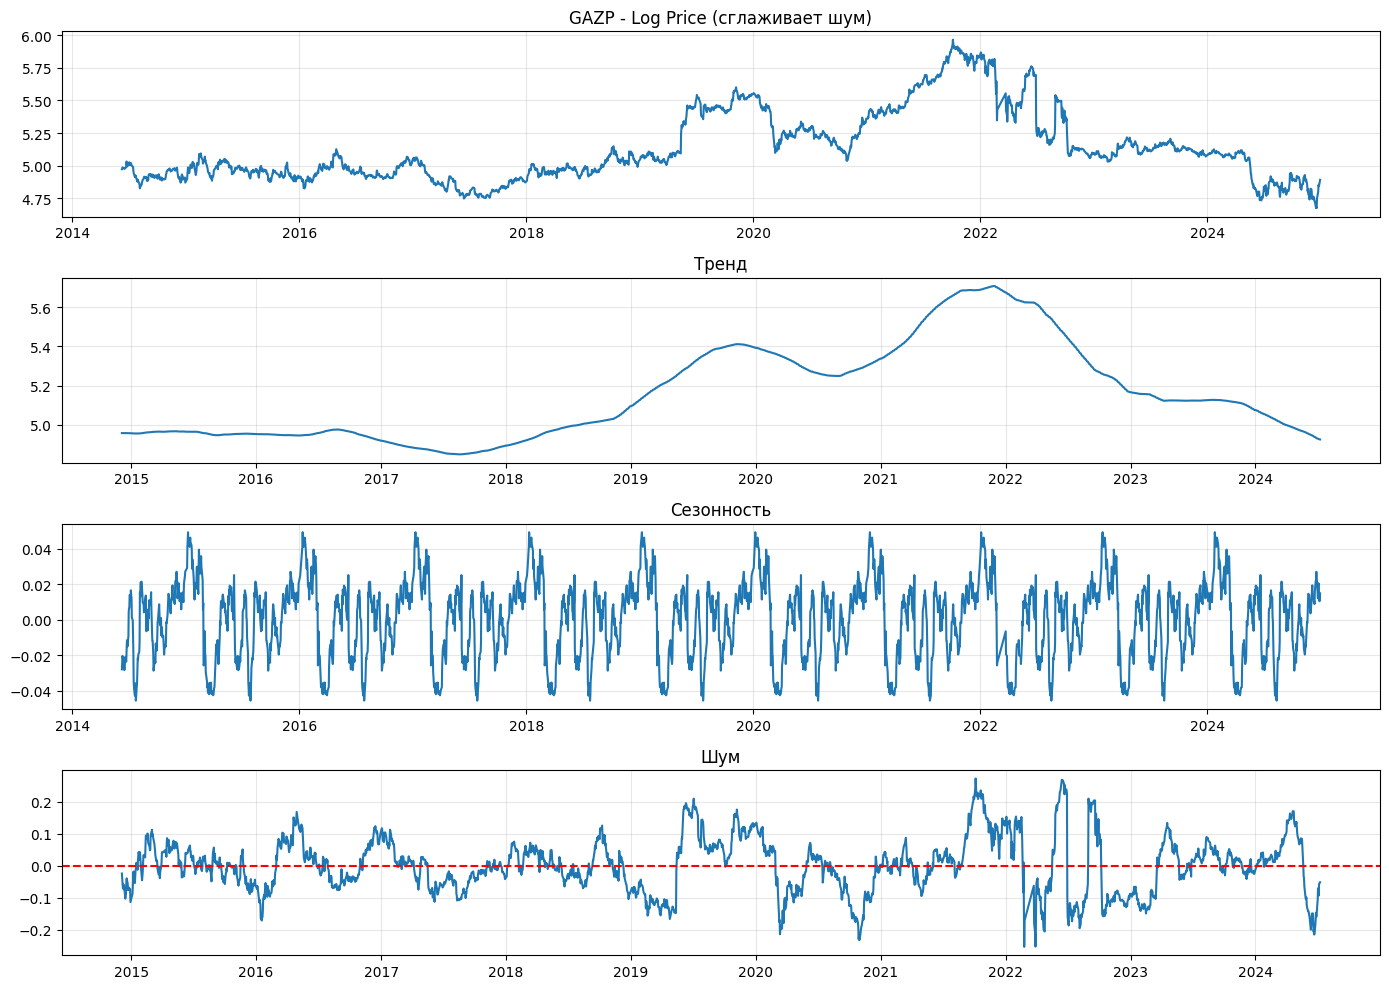

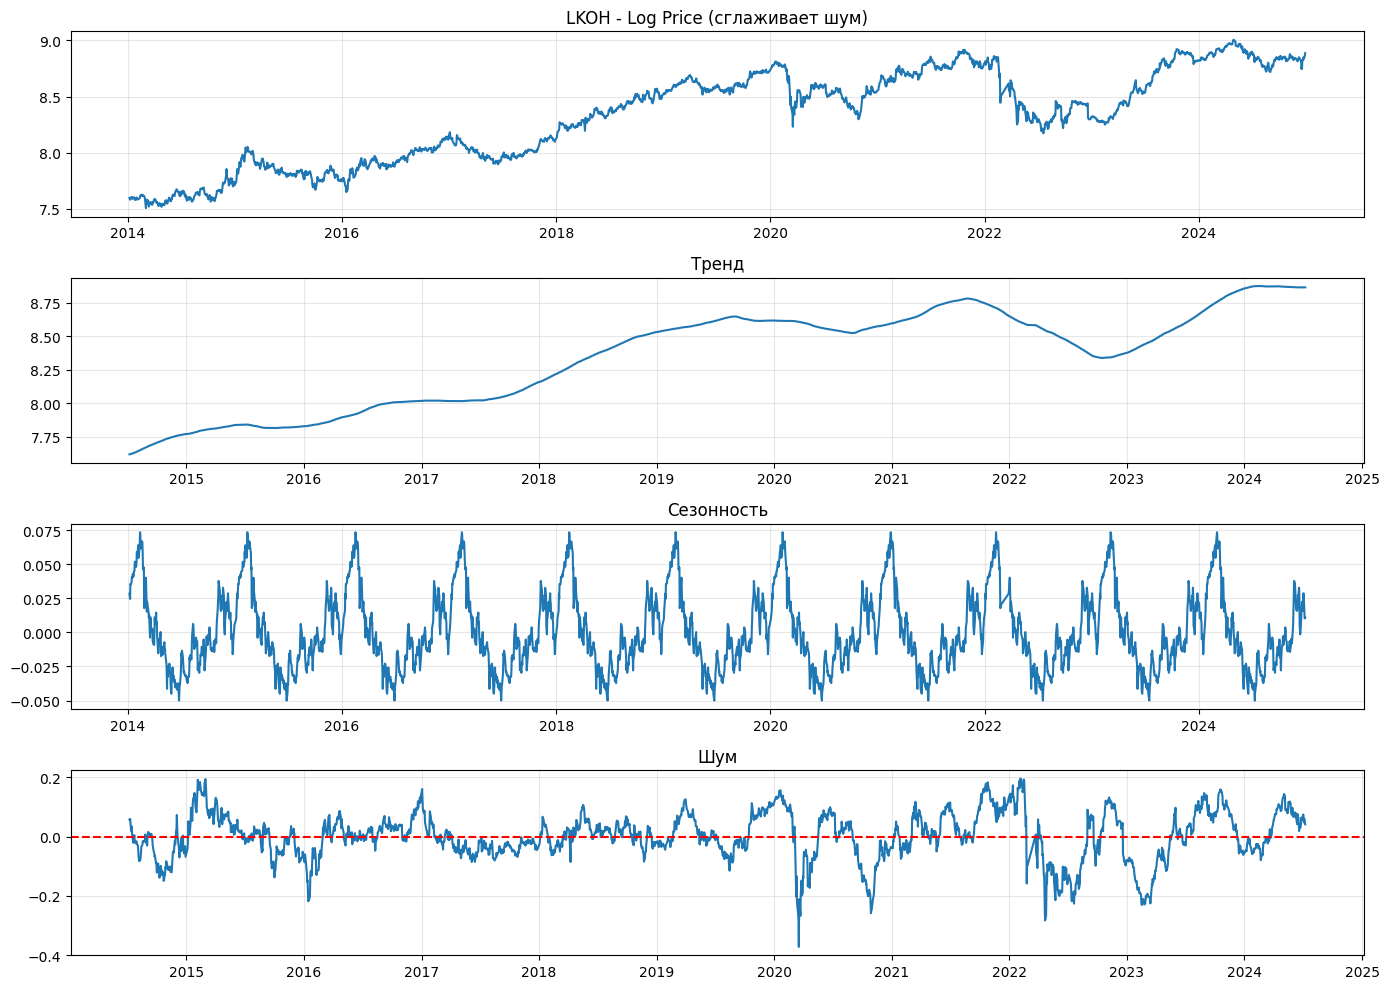

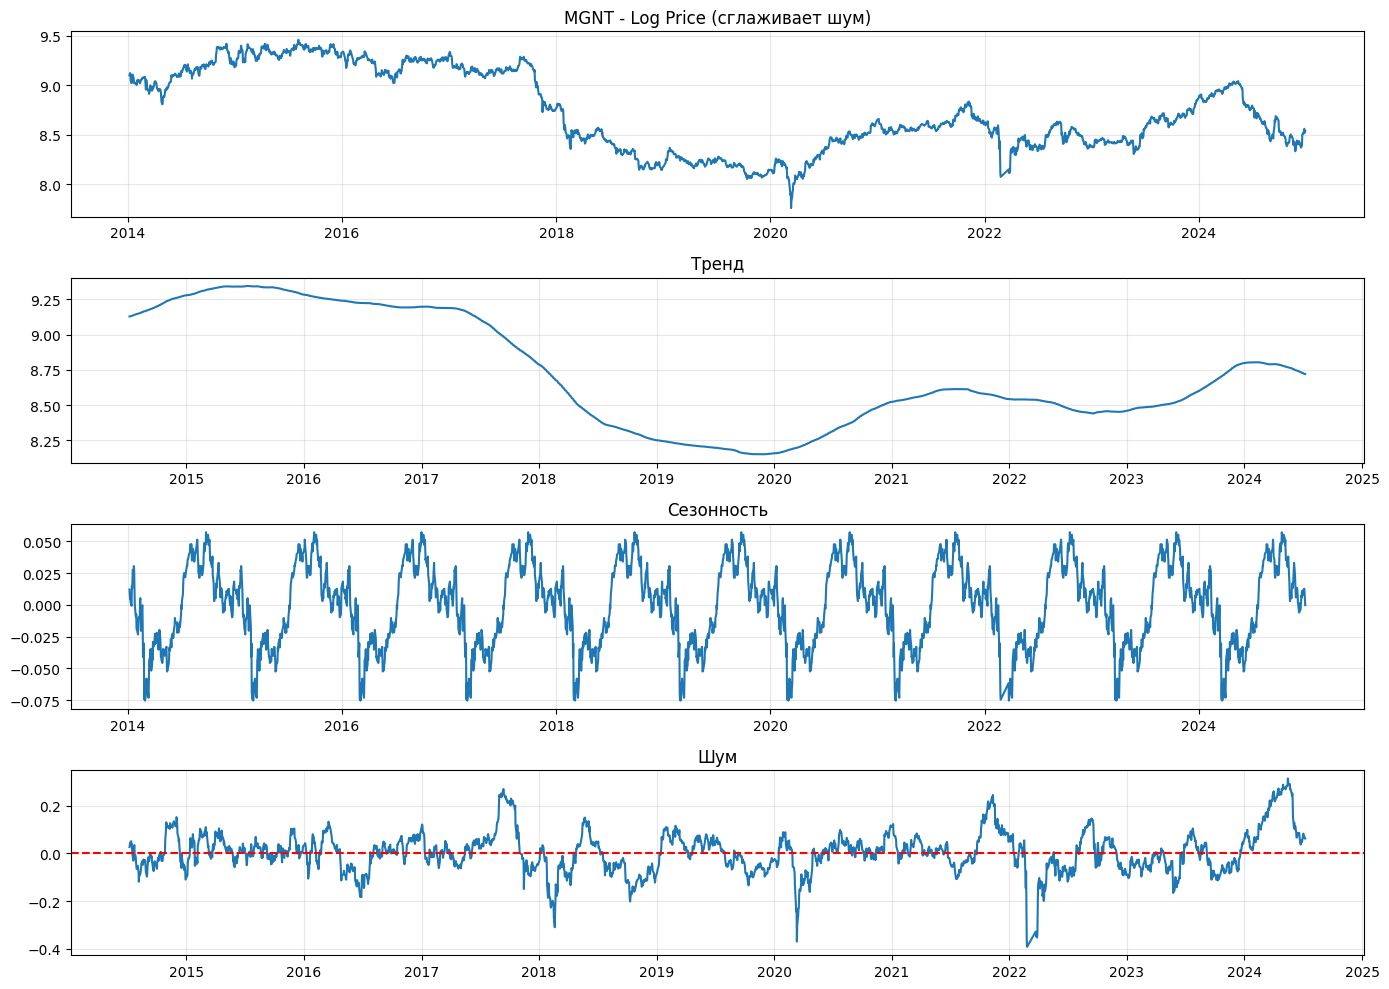

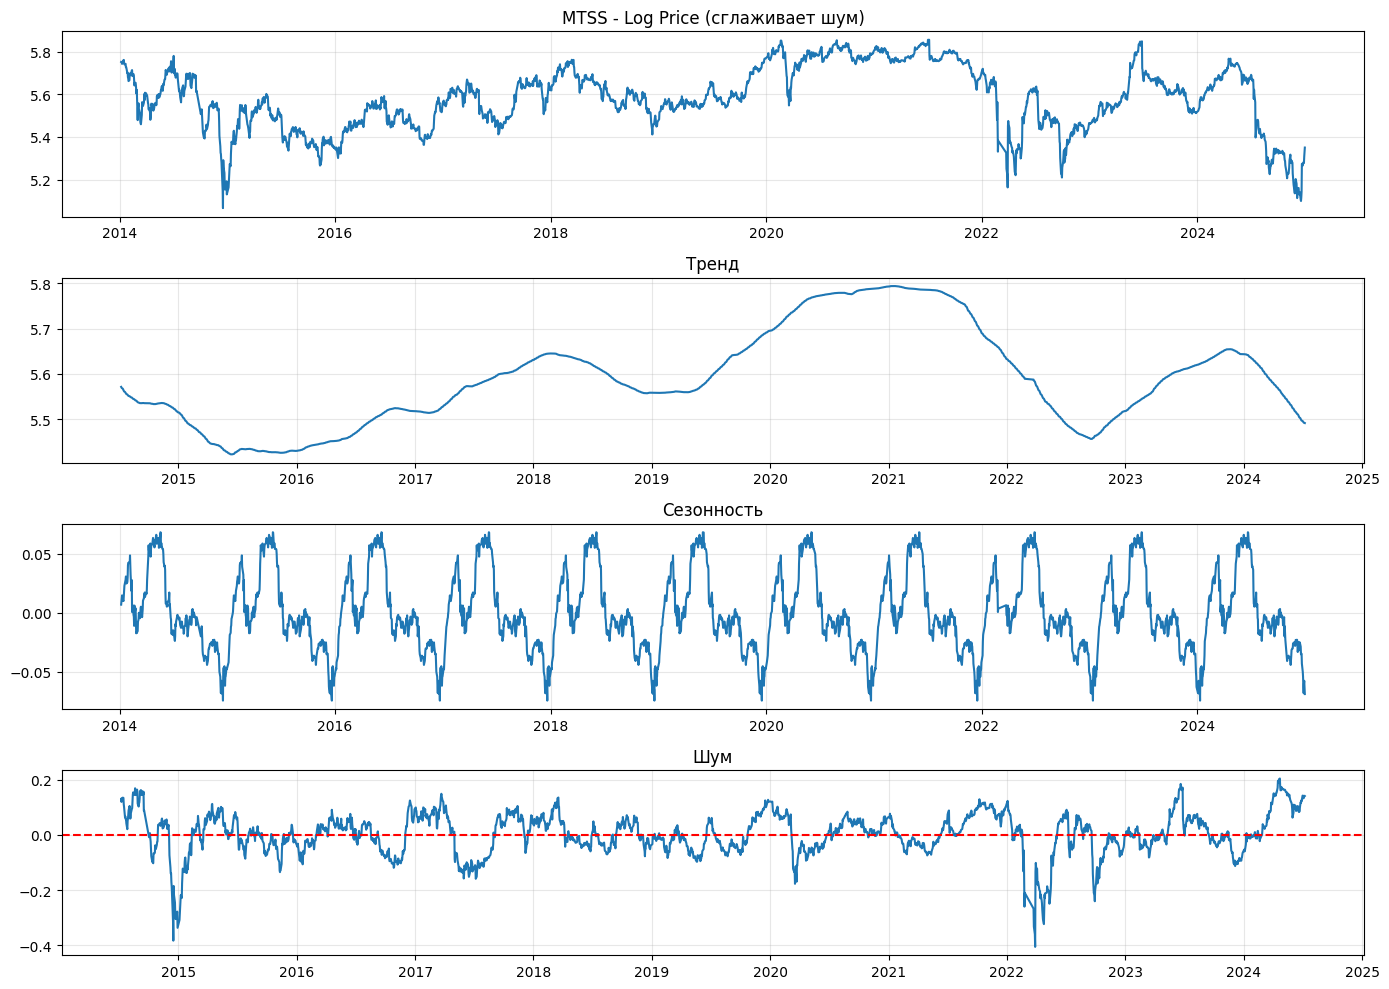

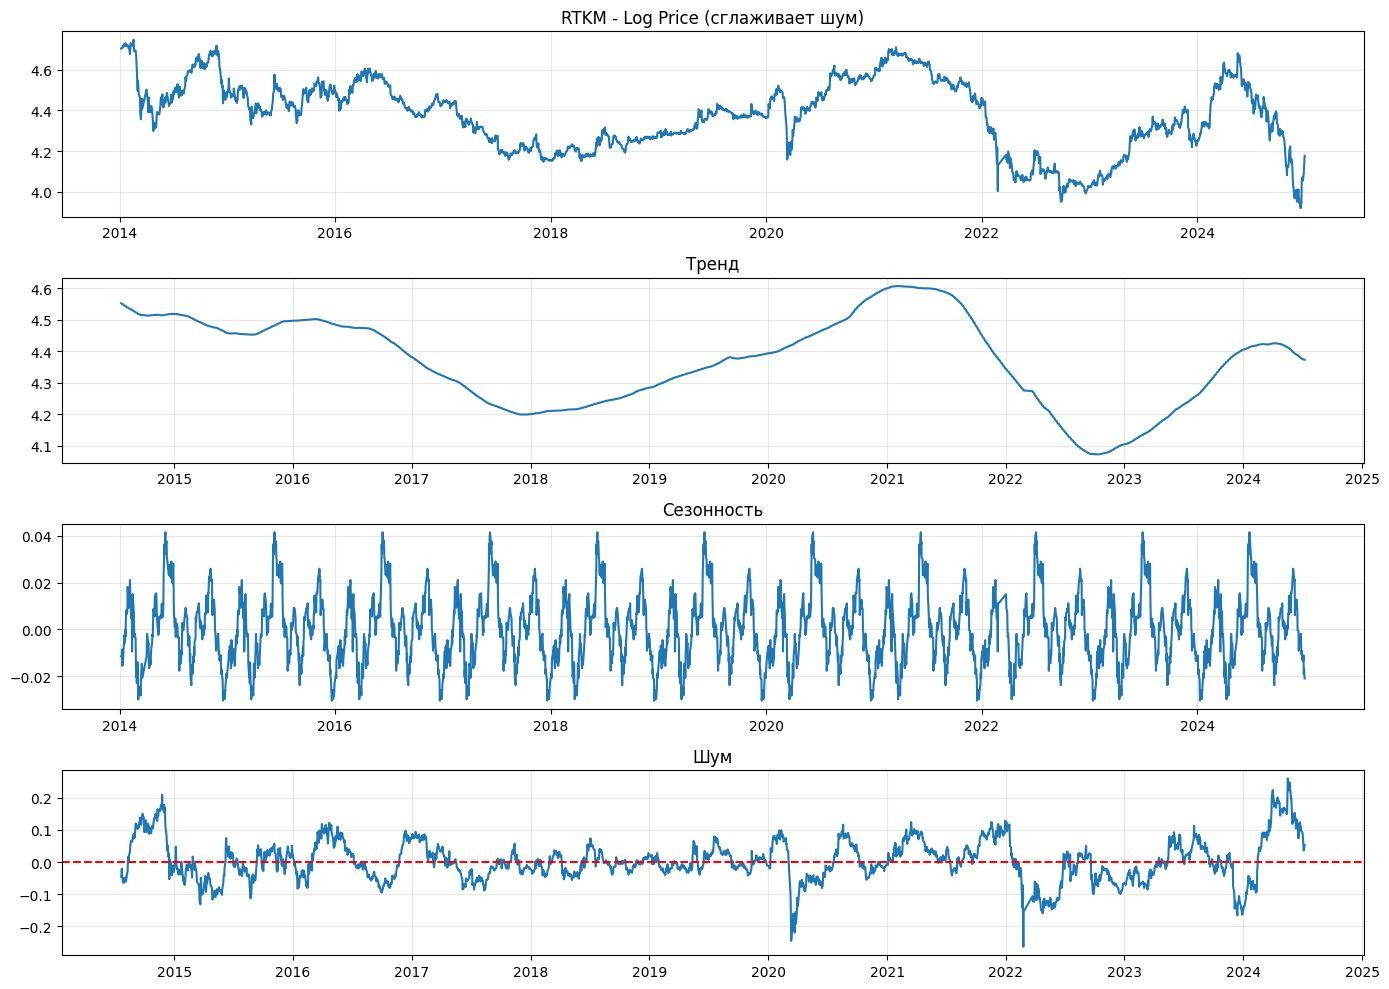

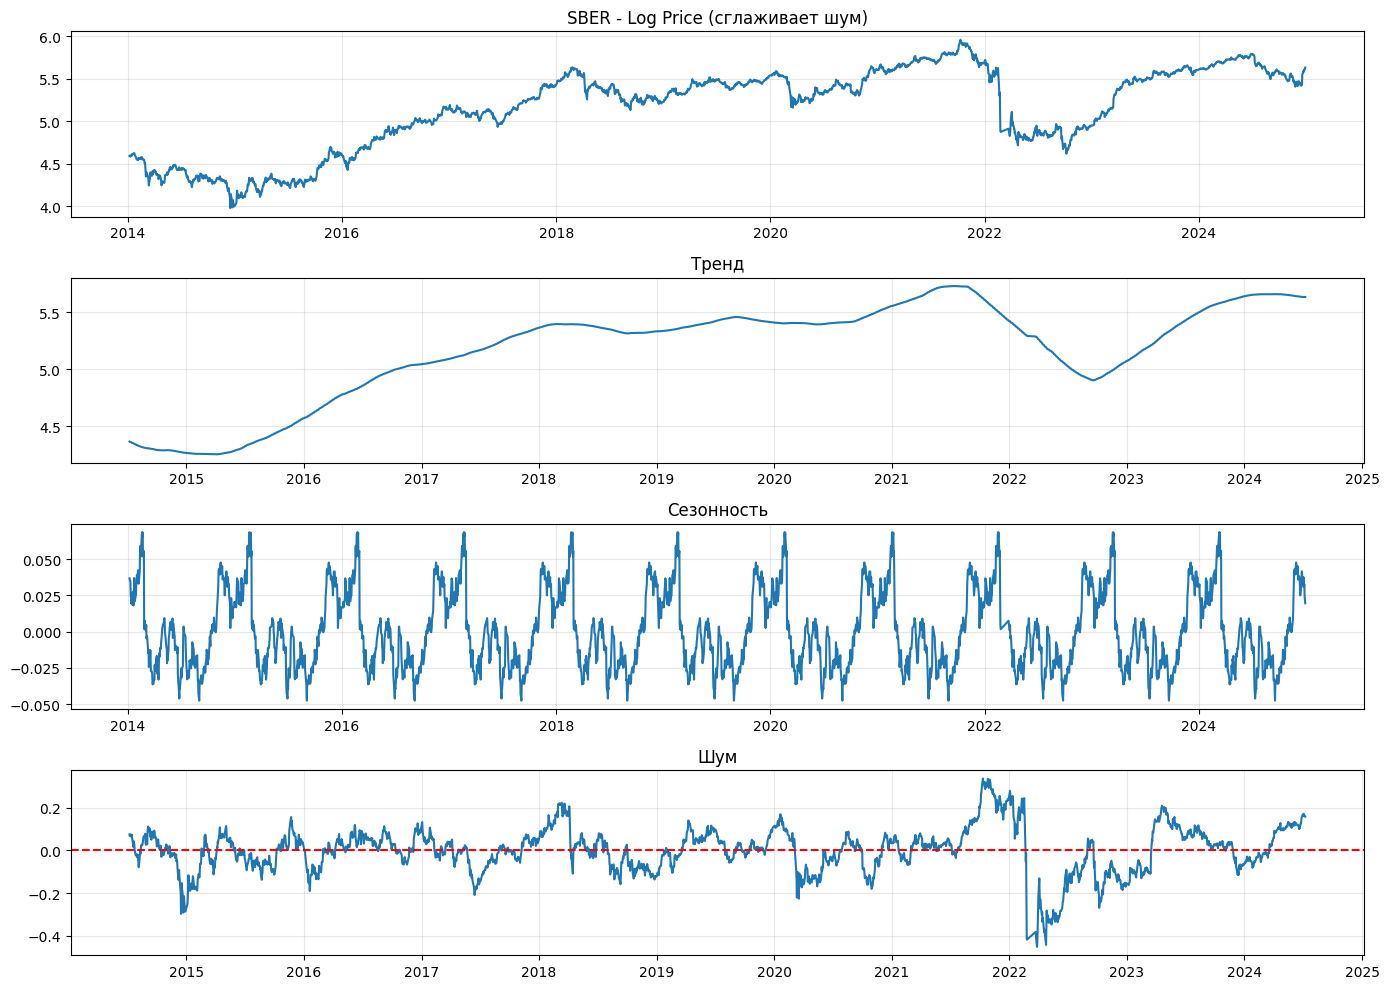

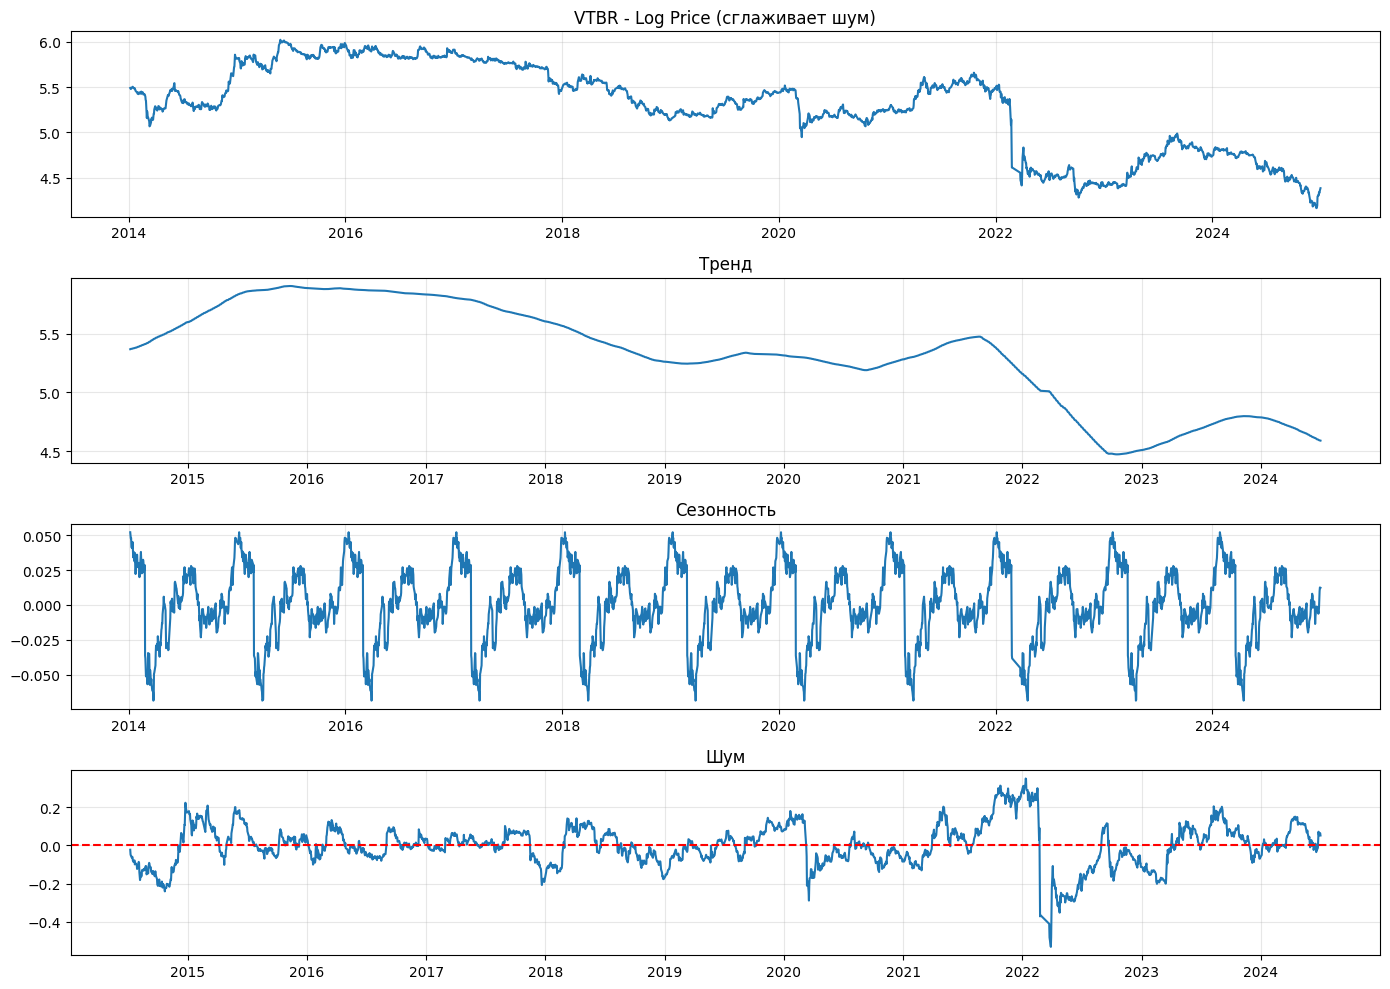

In [4]:
# Делим данные на клмплненты
for col in df_wide.columns:
    series = df_wide[col].dropna()
    
    if len(series) >= 100:
        # ВАЖНО: используем логарифм для всех тикеров
        log_series = np.log(series)
        
        # Период для дневных данных
        period = 252 if len(series) >= 504 else min(20, len(series) // 4)
        
        # Декомпозиция логарифма
        decomposition = seasonal_decompose(log_series, period=period, model='additive')
        
        # Визуализация
        fig, axes = plt.subplots(4, 1, figsize=(14, 10))
        
        axes[0].plot(series.index, log_series)
        axes[0].set_title(f'{col} - Log Price (сглаживает шум)')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(series.index, decomposition.trend)
        axes[1].set_title('Тренд')
        axes[1].grid(True, alpha=0.3)
        
        axes[2].plot(series.index, decomposition.seasonal)
        axes[2].set_title('Сезонность')
        axes[2].grid(True, alpha=0.3)
        
        axes[3].plot(series.index, decomposition.resid)
        axes[3].set_title('Шум')
        axes[3].axhline(y=0, color='r', linestyle='--')
        axes[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## Применяем логарифмирование цены,потому квк без этого был слышком высокий шум это можно объяснить высокими ценами на некоторые акции

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


GAZP: Прогноз = 131.87


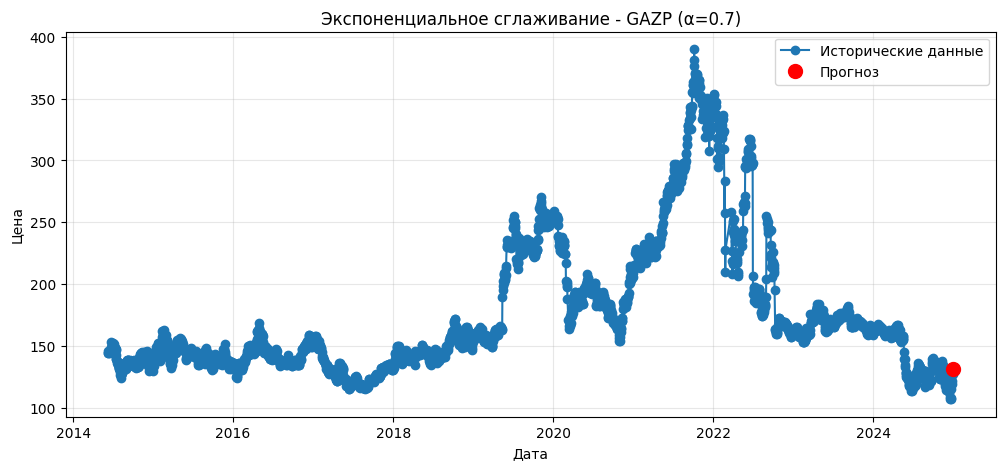

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


LKOH: Прогноз = 7163.06


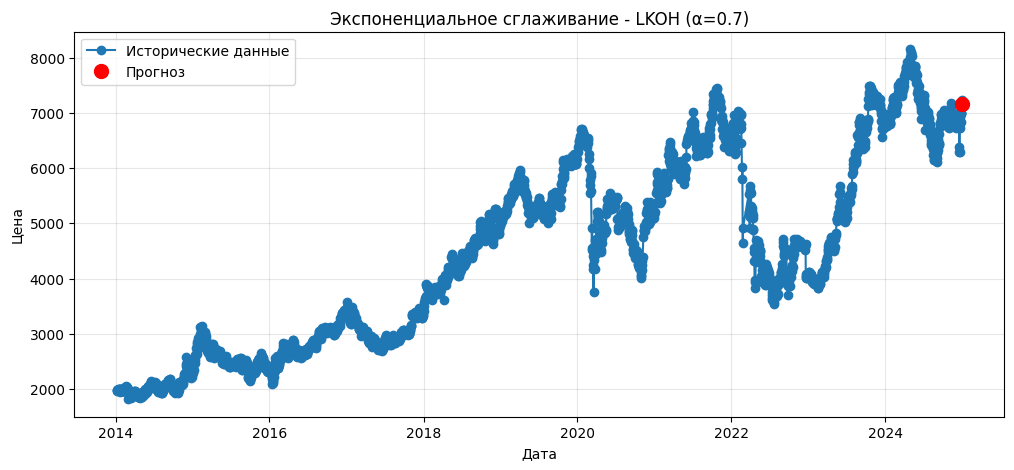

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


MGNT: Прогноз = 5082.81


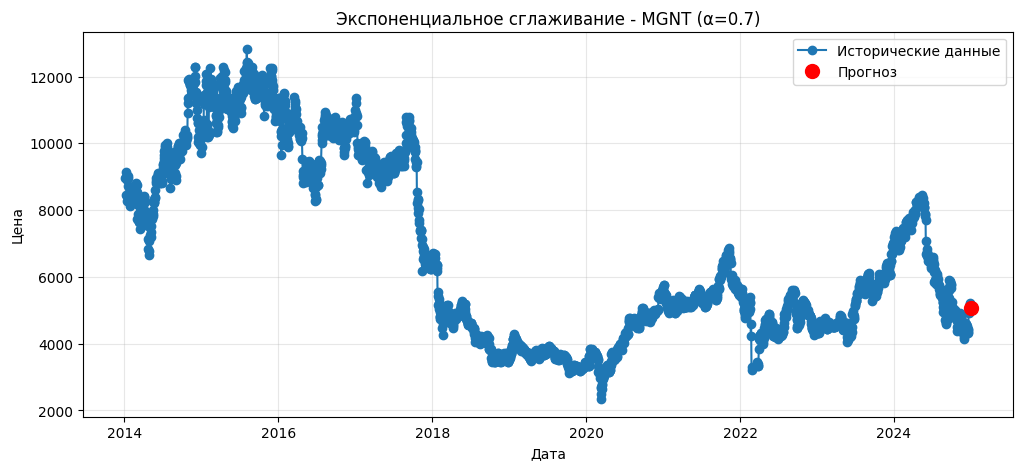

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


MTSS: Прогноз = 207.51


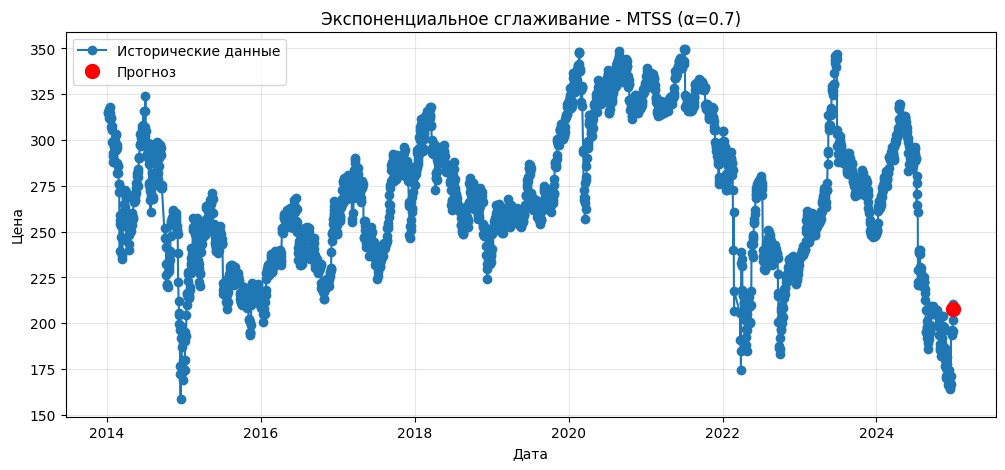

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


RTKM: Прогноз = 63.94


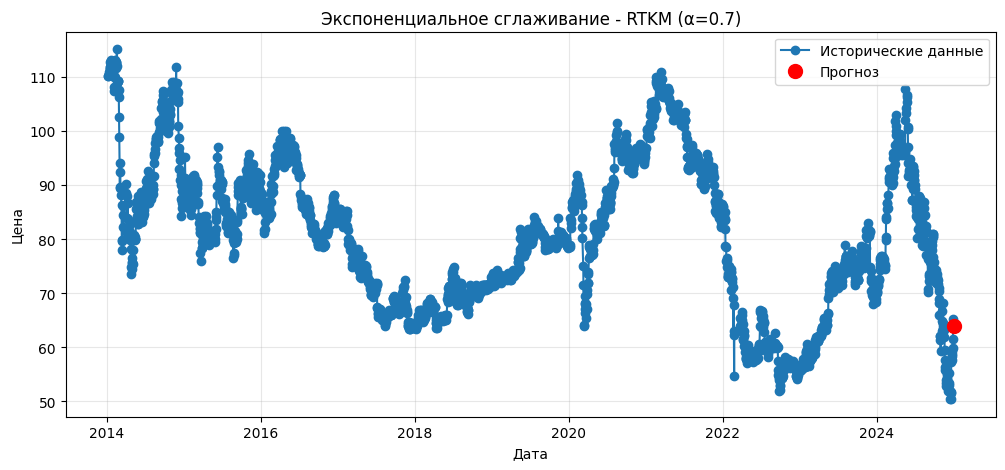

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


SBER: Прогноз = 277.26


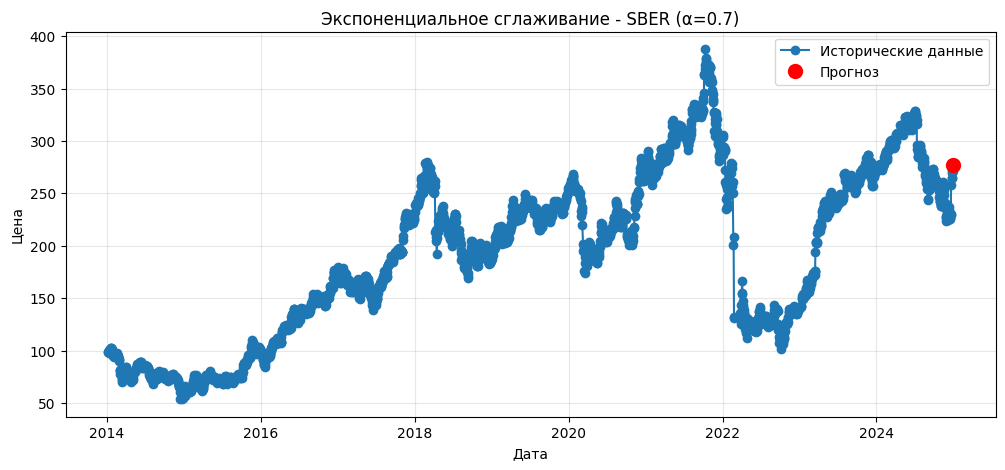

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


VTBR: Прогноз = 79.28


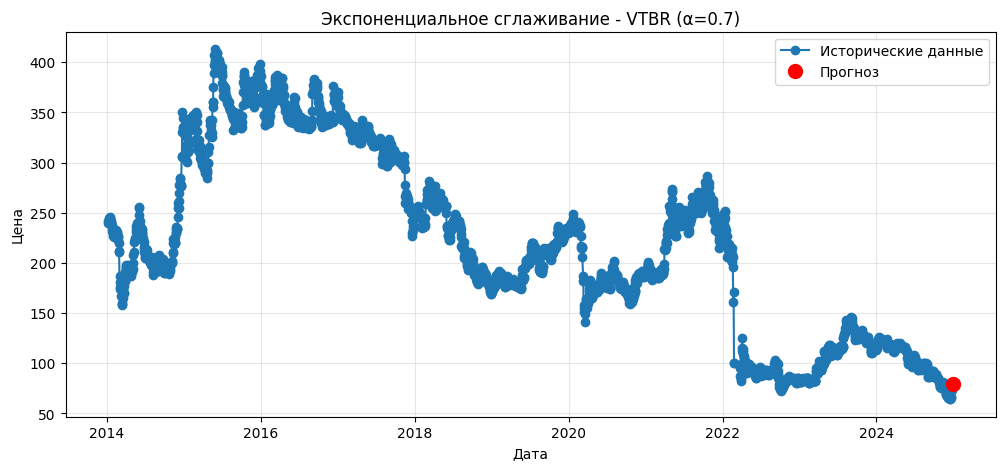

In [5]:
# Экспон.сглаж.
for col in df_wide.columns:
    series = df_wide[col].dropna()
    
    if len(series) >= 10:  # минимум 10 наблюдений
        # Создаем и обучаем модель
        ses = SimpleExpSmoothing(series)
        model = ses.fit(smoothing_level=0.7, optimized=False)
        
        # Прогноз на 1 шаг вперед
        forecast = model.forecast(1)
        
        print(f"{col}: Прогноз = {forecast.iloc[0]:.2f}")
        
        # Визуализация
        plt.figure(figsize=(12, 5))
        plt.plot(series.index, series.values, label='Исторические данные', marker='o')
        
        # Добавляем прогноз
        forecast_index = [series.index[-1] + pd.Timedelta(days=1)]
        plt.plot(forecast_index, forecast, 'ro', label='Прогноз', markersize=10)
        
        plt.title(f'Экспоненциальное сглаживание - {col} (α={0.7})')
        plt.xlabel('Дата')
        plt.ylabel('Цена')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

## Видим что экспоненциальное сглаживание очень хорошо справляется.Да есть разрывы,но это скорее всего не рабочие дни биржи,либо госудаоственные праздники.Ну,а мы покеа пойдём далее...

In [6]:
def stat_test(column_data, column_name):
    test = sm.tsa.adfuller(column_data.dropna())  # убираем пропуски, если есть
    print(f'\n--- Колонка: {column_name} ---')
    print('adf: ', test[0])
    print('p-value: ', test[1])
    print('Critical values: ', test[4])
    
    if test[0] > test[4]['5%']: 
        print('есть единичные корни, ряд не стационарен')
        return False  # не стационарен
    else:
        print('единичных корней нет, ряд стационарен')
        return True   # стационарен

# Цикл по всем колонкам
results = {}
for column in df_wide.columns:
    results[column] = stat_test(df_wide[column], column)




--- Колонка: GAZP ---
adf:  -2.0738050216800747
p-value:  0.25517732698341566
Critical values:  {'1%': np.float64(-3.4328445535976133), '5%': np.float64(-2.8626421034231315), '10%': np.float64(-2.5673566884539056)}
есть единичные корни, ряд не стационарен

--- Колонка: LKOH ---
adf:  -1.3512360939589836
p-value:  0.6054182686536389
Critical values:  {'1%': np.float64(-3.4327476041670137), '5%': np.float64(-2.86259928801764), '10%': np.float64(-2.5673338933837835)}
есть единичные корни, ряд не стационарен

--- Колонка: MGNT ---
adf:  -1.464995199504557
p-value:  0.5507512237241978
Critical values:  {'1%': np.float64(-3.432723240296268), '5%': np.float64(-2.862588528076247), '10%': np.float64(-2.567328164790305)}
есть единичные корни, ряд не стационарен

--- Колонка: MTSS ---
adf:  -3.382508553132853
p-value:  0.011569803924707307
Critical values:  {'1%': np.float64(-3.4327379732269048), '5%': np.float64(-2.862595034666578), '10%': np.float64(-2.567331628897652)}
единичных корней нет, р

# Вполне ожидаемо,что ни один ряд не является стационарным.Проведём дифференцирование

In [7]:
def make_stationary_with_dates(df_wide, max_diff=2):
    """
    Приводит ряды к стационарности и сохраняет даты
    """
    diff_info = {}
    result_data = {}
    
    # Сохраняем исходные даты
    original_dates = df_wide.index
    
    for col in df_wide.columns:
        series = df_wide[col].dropna().values
        d = 0
        current = series.copy()
        
        for d in range(max_diff + 1):
            p_val = sm.tsa.adfuller(current)[1]
            if p_val < 0.05:
                break
            if d < max_diff:
                current = pd.Series(current).diff().dropna().values
        
        result_data[col] = current
        diff_info[col] = d
        status = "стационарен" if d == 0 else f"дифференцирован (d={d})"
        
    
    # Находим минимальную длину
    min_len = min(len(v) for v in result_data.values())
    
    # Обрезаем все до минимальной длины
    for col in result_data:
        result_data[col] = result_data[col][:min_len]
    
    # Создаем DataFrame
    result_df = pd.DataFrame(result_data)
    
    # Добавляем даты (сдвигаем на количество потерянных строк)
    # Потеряно строк = len(original_dates) - min_len
    lost_rows = len(original_dates) - min_len
    result_df.index = original_dates[lost_rows:]
    
   
    
    return result_df, diff_info

# Использование:
df_wide_stationary, diff_orders = make_stationary_with_dates(df_wide)


In [8]:
def stat_test(column_data, column_name):
    test = sm.tsa.adfuller(column_data.dropna())  # убираем пропуски, если есть
    print(f'\n--- Колонка: {column_name} ---')
    print('adf: ', test[0])
    print('p-value: ', test[1])
    print('Critical values: ', test[4])
    
    if test[0] > test[4]['5%']: 
        print('есть единичные корни, ряд не стационарен')
        return False  # не стационарен
    else:
        print('единичных корней нет, ряд стационарен')
        return True   # стационарен

# Цикл по всем колонкам
results = {}
for column in df_wide.columns:
    results[column] = stat_test(df_wide_stationary[column], column)




--- Колонка: GAZP ---
adf:  -10.221547026929628
p-value:  5.3086028626973e-18
Critical values:  {'1%': np.float64(-3.4328445535976133), '5%': np.float64(-2.8626421034231315), '10%': np.float64(-2.5673566884539056)}
единичных корней нет, ряд стационарен

--- Колонка: LKOH ---
adf:  -8.957414974190264
p-value:  8.40081623366468e-15
Critical values:  {'1%': np.float64(-3.4328445535976133), '5%': np.float64(-2.8626421034231315), '10%': np.float64(-2.5673566884539056)}
единичных корней нет, ряд стационарен

--- Колонка: MGNT ---
adf:  -50.24380563215389
p-value:  0.0
Critical values:  {'1%': np.float64(-3.4328191223134246), '5%': np.float64(-2.862630872437016), '10%': np.float64(-2.567350709015523)}
единичных корней нет, ряд стационарен

--- Колонка: MTSS ---
adf:  -3.535094712033574
p-value:  0.0071302270053869455
Critical values:  {'1%': np.float64(-3.4328266032869332), '5%': np.float64(-2.8626341762010505), '10%': np.float64(-2.5673524679558892)}
единичных корней нет, ряд стационарен

-

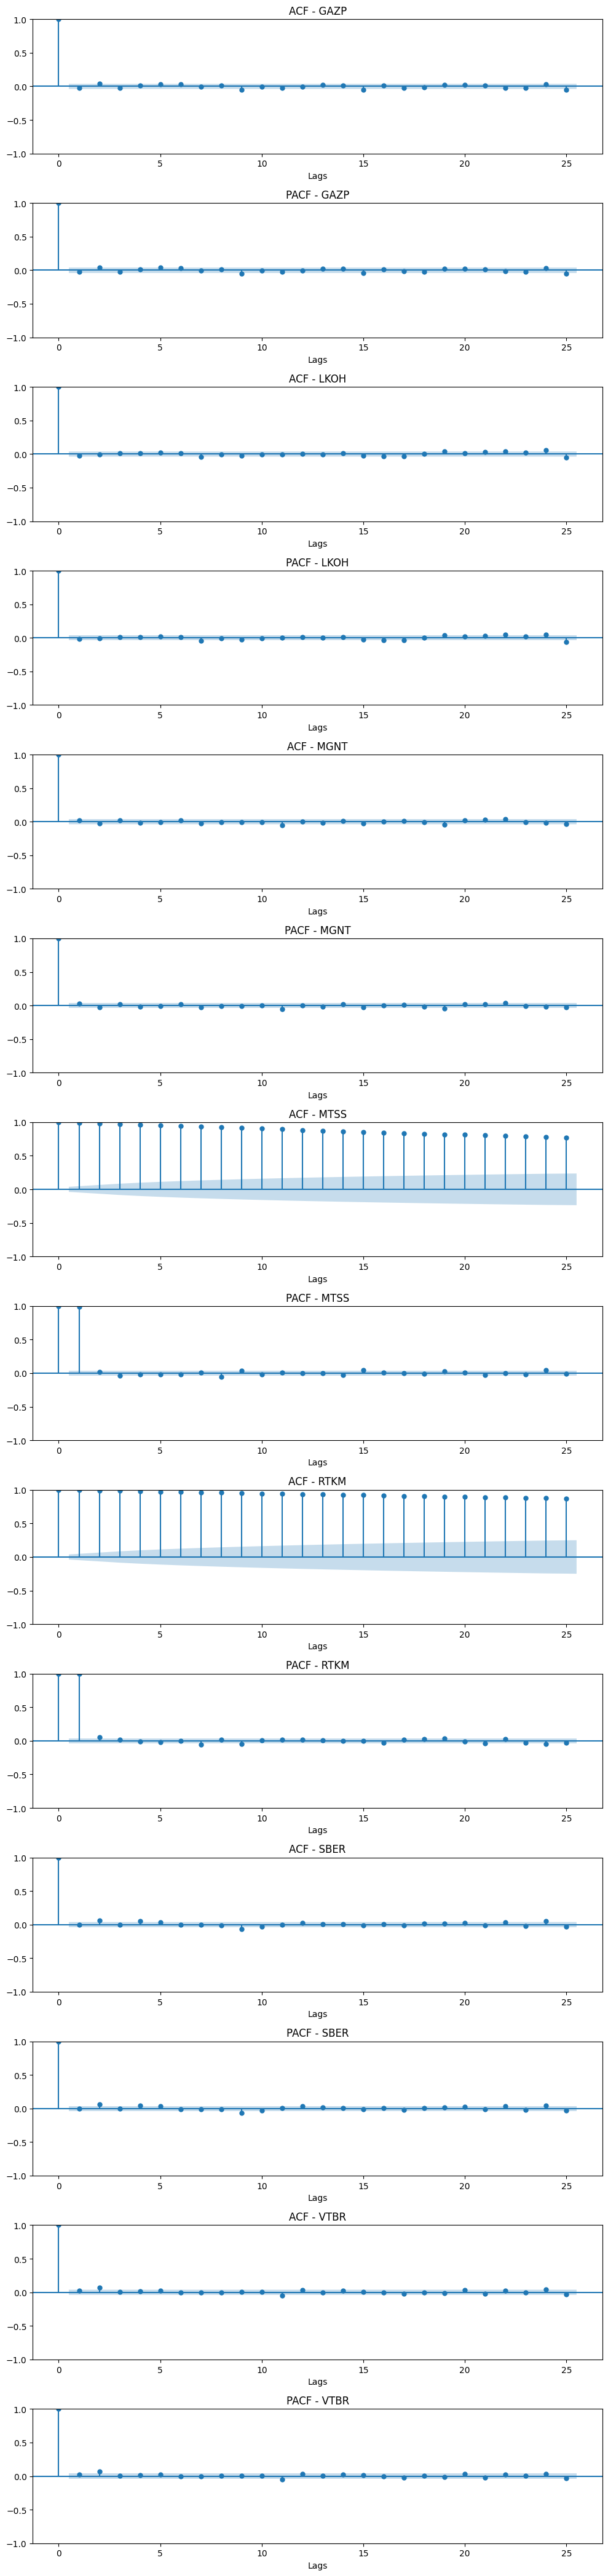

In [9]:
def plot_acf_pacf_grid(data, lags=25, cols_per_row=2):
    """
    Строит сетку графиков ACF и PACF для всех колонок
    """
    n_cols = len(data.columns)
    n_rows = n_cols * 2  # для каждой колонки ACF и PACF
    
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 3 * n_rows))
    
    for i, col in enumerate(data.columns):
        # ACF
        sm.graphics.tsa.plot_acf(data[col].dropna(), lags=lags, ax=axes[i*2])
        axes[i*2].set_title(f'ACF - {col}')
        axes[i*2].set_xlabel('Lags')
        
        # PACF
        sm.graphics.tsa.plot_pacf(data[col].dropna(), lags=lags, ax=axes[i*2 + 1])
        axes[i*2 + 1].set_title(f'PACF - {col}')
        axes[i*2 + 1].set_xlabel('Lags')
    
    plt.tight_layout()
    plt.show()

# Использование:
plot_acf_pacf_grid(df_wide_stationary, lags=25)

## Видим не хорошие признаки,похжие нв не стационарность в тикерах MTSS и RTKM.Проведём логарифмирование и дифференцацию и проверим ещё раз при помощи теста Дики-Фуллера

In [10]:
df_wide_stationary.head(5)

,GAZP,LKOH,MGNT,MTSS,RTKM,SBER,VTBR
begin,,,,,,,
2014-06-10,0.35,-31.1,198.0,315.02,110.29,-0.72,-2.75
2014-06-11,1.65,20.0,-164.4,314.63,110.25,-0.19,1.05
2014-06-16,-1.20,12.5,-540.4,312.04,110.65,1.20,1.70
2014-06-17,-0.43,9.5,-191.6,313.43,110.99,1.05,2.30
2014-06-18,0.23,-21.1,155.5,317.08,111.92,-1.01,0.95


In [11]:
df_wide_stationary['MTSS'] = df_wide_stationary['MTSS'].diff()
df_wide_stationary['RTKM'] = df_wide_stationary['RTKM'].diff()

df_wide_stationary.dropna()
df_wide_stationary.head(5)


,GAZP,LKOH,MGNT,MTSS,RTKM,SBER,VTBR
begin,,,,,,,
2014-06-10,0.35,-31.1,198.0,NaN,NaN,-0.72,-2.75
2014-06-11,1.65,20.0,-164.4,-0.39,-0.04,-0.19,1.05
2014-06-16,-1.20,12.5,-540.4,-2.59,0.40,1.20,1.70
2014-06-17,-0.43,9.5,-191.6,1.39,0.34,1.05,2.30
2014-06-18,0.23,-21.1,155.5,3.65,0.93,-1.01,0.95


In [12]:
results = {}
for column in df_wide.columns:
    results[column] = stat_test(df_wide_stationary[column], column)


results


--- Колонка: GAZP ---
adf:  -10.221547026929628
p-value:  5.3086028626973e-18
Critical values:  {'1%': np.float64(-3.4328445535976133), '5%': np.float64(-2.8626421034231315), '10%': np.float64(-2.5673566884539056)}
единичных корней нет, ряд стационарен

--- Колонка: LKOH ---
adf:  -8.957414974190264
p-value:  8.40081623366468e-15
Critical values:  {'1%': np.float64(-3.4328445535976133), '5%': np.float64(-2.8626421034231315), '10%': np.float64(-2.5673566884539056)}
единичных корней нет, ряд стационарен

--- Колонка: MGNT ---
adf:  -50.24380563215389
p-value:  0.0
Critical values:  {'1%': np.float64(-3.4328191223134246), '5%': np.float64(-2.862630872437016), '10%': np.float64(-2.567350709015523)}
единичных корней нет, ряд стационарен

--- Колонка: MTSS ---
adf:  -17.78949743129865
p-value:  3.251747656993745e-30
Critical values:  {'1%': np.float64(-3.4328266032869332), '5%': np.float64(-2.8626341762010505), '10%': np.float64(-2.5673524679558892)}
единичных корней нет, ряд стационарен

-

{'GAZP': True,
 'LKOH': True,
 'MGNT': True,
 'MTSS': True,
 'RTKM': True,
 'SBER': True,
 'VTBR': True}

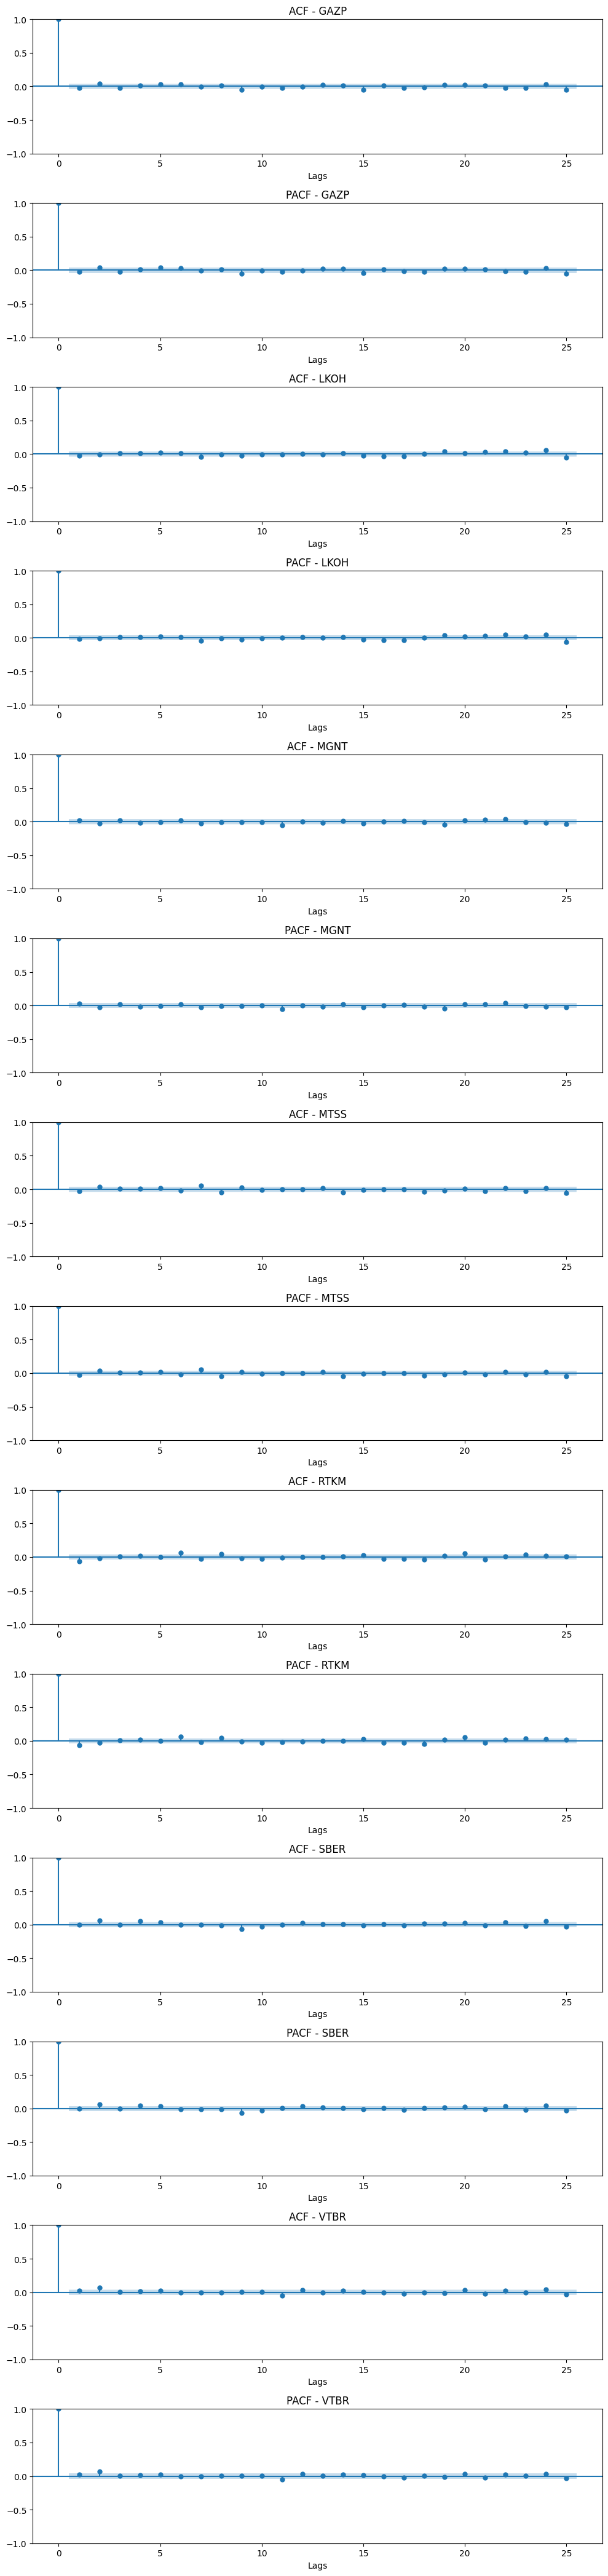

In [13]:
# И для полной уверености снова глянем на гшрафики
plot_acf_pacf_grid(df_wide_stationary, lags=25)

## Отлично,ряды стационарны и их можно прогнозировать.Приступим к обучению моделей

# AR Model

In [14]:
train = df_wide_stationary[df_wide_stationary.index < '2021-01-01']
test = df_wide_stationary[df_wide_stationary.index >= '2021-01-01']

In [15]:
from statsmodels.tsa.api import VAR
# Подготовка данных: удаляем строки с NaN
train_clean = train.dropna()
test_clean = test.dropna()

print(f"Train shape after cleaning: {train_clean.shape}")
print(f"Test shape after cleaning: {test_clean.shape}")

# Выбор оптимального количества лагов
var_model = VAR(train_clean)
lag_order = var_model.select_order(maxlags=25)
print(lag_order.summary())

# Оптимальное количество лагов по AIC
optimal_lags = lag_order.aic
print(f"\nOptimal lags (AIC): {optimal_lags}")

# Обучение модели
var_fitted = var_model.fit(maxlags=optimal_lags if optimal_lags > 0 else 8)
print(var_fitted.summary())

# Прогнозирование
lag_order_used = var_fitted.k_ar
forecast = var_fitted.forecast(
    train_clean.values[-lag_order_used:], 
    steps=len(test_clean)
)

forecast_df_VAR = pd.DataFrame(
    forecast, 
    index=test_clean.index, 
    columns=train_clean.columns
)



Train shape after cleaning: (1652, 7)
Test shape after cleaning: (999, 7)


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        29.22      29.24*   4.890e+12      29.23*
1        29.21       29.40   4.862e+12       29.28
2        29.22       29.57   4.900e+12       29.35
3        29.26       29.77   5.087e+12       29.45
4        29.28       29.96   5.214e+12       29.53
5        29.30       30.14   5.329e+12       29.61
6        29.31       30.31   5.384e+12       29.68
7        29.34       30.50   5.531e+12       29.77
8       29.12*       30.44  4.434e+12*       29.61
9        29.14       30.63   4.538e+12       29.69
10       29.17       30.82   4.668e+12       29.78
11       29.19       31.00   4.769e+12       29.86
12       29.21       31.18   4.851e+12       29.94
13       29.23       31.36   4.948e+12       30.02
14       29.26       31.55   5.084e+12       30.11
15       29.28       31.74   5.226e+12       30.20
16       29.30       31.93   5.


ОЦЕНКА КАЧЕСТВА ПРОГНОЗА

GAZP:
  MAE: 3.1916
  RMSE: 6.5754

LKOH:
  MAE: 74.9019
  RMSE: 114.4155

MGNT:
  MAE: 74.1278
  RMSE: 111.7649

MTSS:
  MAE: 2.7749
  RMSE: 5.0718

RTKM:
  MAE: 0.8886
  RMSE: 1.3477

SBER:
  MAE: 3.1174
  RMSE: 5.2974

VTBR:
  MAE: 2.3136
  RMSE: 4.2021


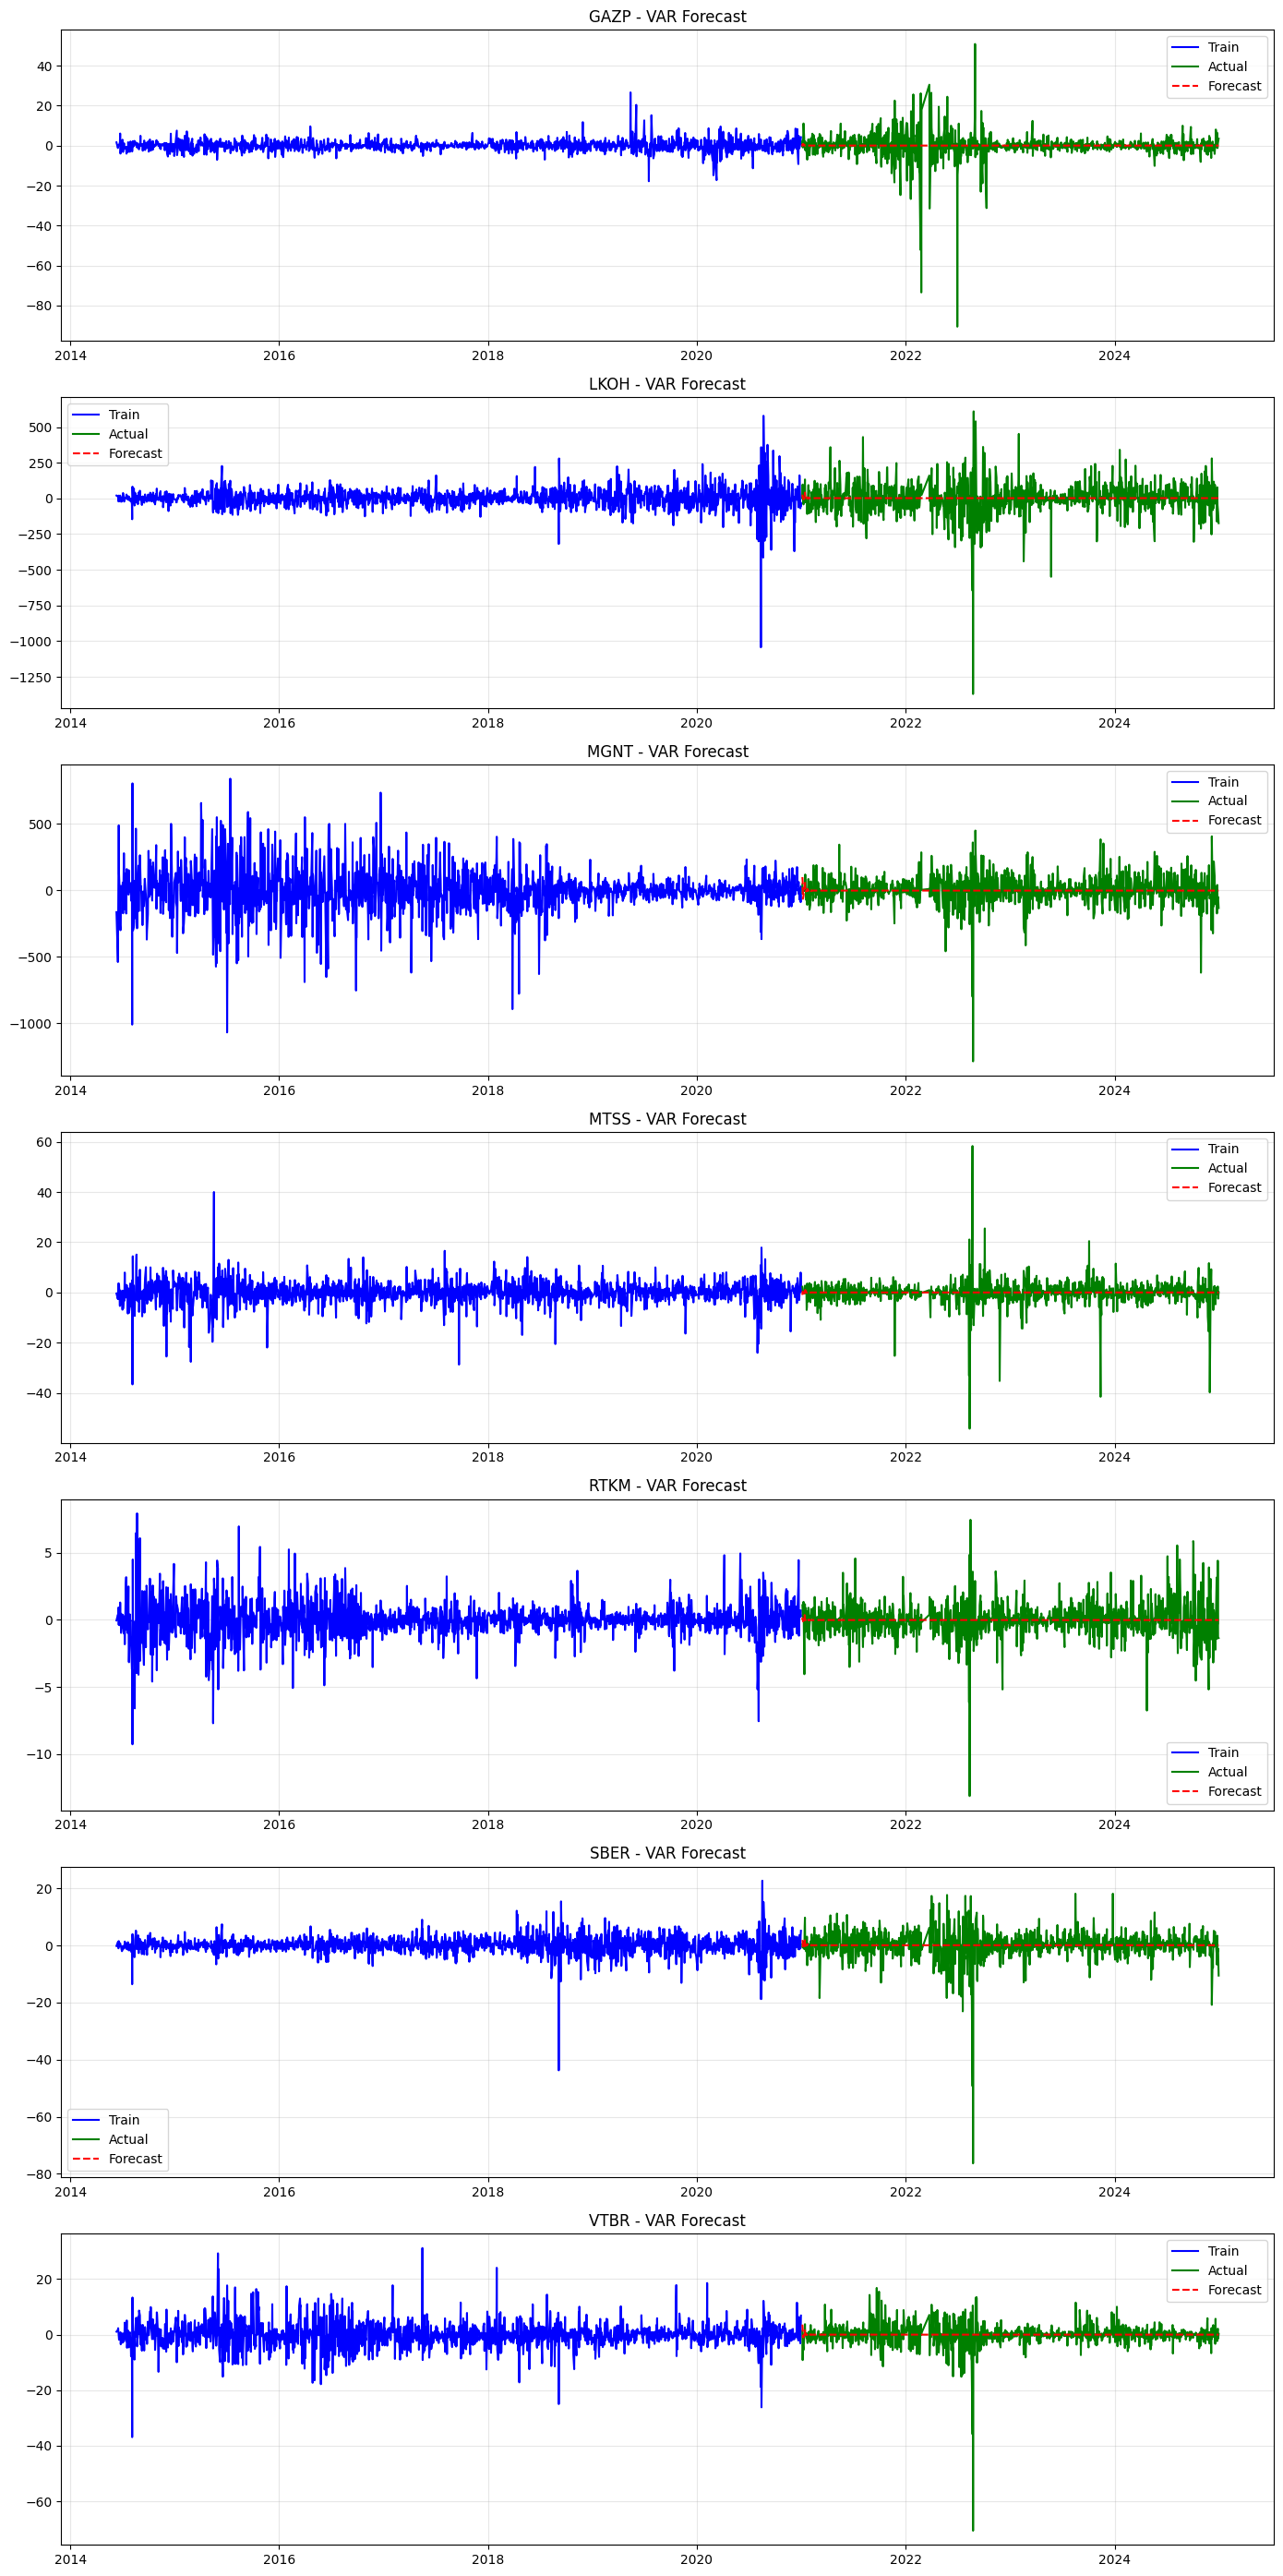


СВОДНАЯ ТАБЛИЦА ОШИБОК
          MAE      RMSE
GAZP   3.1916    6.5754
LKOH  74.9019  114.4155
MGNT  74.1278  111.7649
MTSS   2.7749    5.0718
RTKM   0.8886    1.3477
SBER   3.1174    5.2974
VTBR   2.3136    4.2021

Результаты сохранены в 'VAR_forecast_comparison.csv'


In [16]:
# 1. Сравнение прогноза с фактическими значениями
print("\n" + "="*50)
print("ОЦЕНКА КАЧЕСТВА ПРОГНОЗА")
print("="*50)

for col in test_clean.columns:
    mae = mean_absolute_error(test_clean[col], forecast_df_VAR[col])
    rmse = np.sqrt(mean_squared_error(test_clean[col], forecast_df_VAR[col]))
   
    
    print(f"\n{col}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    

# 2. Визуализация
import matplotlib.pyplot as plt

n_plots = len(train_clean.columns)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4*n_plots))

if n_plots == 1:
    axes = [axes]

for i, col in enumerate(train_clean.columns):
    axes[i].plot(train_clean.index, train_clean[col], label='Train', color='blue')
    axes[i].plot(test_clean.index, test_clean[col], label='Actual', color='green')
    axes[i].plot(forecast_df_VAR.index, forecast_df_VAR[col], label='Forecast', color='red', linestyle='--')
    axes[i].set_title(f'{col} - VAR Forecast')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Ошибка по всем тикерам (сводка)
print("\n" + "="*50)
print("СВОДНАЯ ТАБЛИЦА ОШИБОК")
print("="*50)

errors_df = pd.DataFrame({
    'MAE': [mean_absolute_error(test_clean[col], forecast_df_VAR[col]) for col in test_clean.columns],
    'RMSE': [np.sqrt(mean_squared_error(test_clean[col], forecast_df_VAR[col])) for col in test_clean.columns],
    
}, index=test_clean.columns)

print(errors_df.round(4))

# 4. Сохраните прогноз и факт для дальнейшего анализа
comparison_df = pd.DataFrame()
for col in test_clean.columns:
    comparison_df[f'{col}_actual'] = test_clean[col]
    comparison_df[f'{col}_forecast'] = forecast_df_VAR[col]

comparison_df.to_csv('VAR_forecast_comparison.csv')
print("\nРезультаты сохранены в 'VAR_forecast_comparison.csv'")

## Авторегрессия тоже хопрошо справилась со своей работой.Продолжим далее...


# MA Model

In [17]:
# Прогноз с помощью скользящего среднего
window = 20  # окно для сглаживания

for col in df_wide_stationary.columns:
    series = df_wide_stationary[col].dropna()
    
    # Скользящее среднее
    ma = series.rolling(window=window).mean()
    
    # Прогноз: последнее значение MA
    forecast_ma = ma.iloc[-1]
    
    # Простой прогноз на следующий период
    last_values = series.iloc[-window:]
    forecast_simple = last_values.mean()
    
    print(f"\n{col}:")
    print(f"  MA({window}) прогноз: {forecast_ma:.2f}")
    print(f"  Простой прогноз: {forecast_simple:.2f}")
    print(f"  Последняя цена: {series.iloc[-1]:.2f}")


GAZP:
  MA(20) прогноз: 0.58
  Простой прогноз: 0.58
  Последняя цена: 3.52

LKOH:
  MA(20) прогноз: -33.98
  Простой прогноз: -33.98
  Последняя цена: -173.50

MGNT:
  MA(20) прогноз: -44.35
  Простой прогноз: -44.35
  Последняя цена: -134.00

MTSS:
  MA(20) прогноз: -0.32
  Простой прогноз: -0.32
  Последняя цена: 0.10

RTKM:
  MA(20) прогноз: -0.19
  Простой прогноз: -0.19
  Последняя цена: -1.35

SBER:
  MA(20) прогноз: -2.43
  Простой прогноз: -2.43
  Последняя цена: -10.55

VTBR:
  MA(20) прогноз: -0.13
  Простой прогноз: -0.13
  Последняя цена: 0.24


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

window = 20

for col in df_wide_stationary.columns:
    series = df_wide_stationary[col].dropna()
    
    
    predictions = []
    actuals = []
    
    for i in range(window, len(series)):
        train = series.iloc[i-window:i]
        pred = train.mean()
        predictions.append(pred)
        actuals.append(series.iloc[i])
    
    # Оценка качества
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    
    print(f"\n{col}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    


GAZP:
  MAE: 2.47
  RMSE: 4.68

LKOH:
  MAE: 57.34
  RMSE: 92.25

MGNT:
  MAE: 99.43
  RMSE: 151.20

MTSS:
  MAE: 3.08
  RMSE: 4.92

RTKM:
  MAE: 0.90
  RMSE: 1.36

SBER:
  MAE: 2.63
  RMSE: 4.26

VTBR:
  MAE: 2.99
  RMSE: 4.69


## Скользящее средне показало себя пока что найлучшим образом.Продолжим эксперимеенты с моделями...

In [19]:
p, d, q = 1, 1, 1  

for col in df_wide_stationary.columns:
    series = df_wide_stationary[col].dropna()
    
    # Модель с d=1 для всех
    arima = ARIMA(series, order=(p, d, q))
    result = arima.fit()
    
    print(result.summary())

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   GAZP   No. Observations:                 2652
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7785.967
Date:                Sat, 11 Apr 2026   AIC                          15577.933
Time:                        18:25:19   BIC                          15595.581
Sample:                             0   HQIC                         15584.321
                               - 2652                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0200      0.006     -3.441      0.001      -0.031      -0.009
ma.L1         -1.0000      0.031    -32.003      0.000      -1.061      -0.939
sigma2        20.7625      0.666     31.159      0.0

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   LKOH   No. Observations:                 2652
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -15681.944
Date:                Sat, 11 Apr 2026   AIC                          31369.888
Time:                        18:25:20   BIC                          31387.536
Sample:                             0   HQIC                         31376.276
                               - 2652                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0194      0.009     -2.184      0.029      -0.037      -0.002
ma.L1         -1.0000      0.068    -14.692      0.000      -1.133      -0.867
sigma2      8023.4263    536.684     14.950      0.0

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


...

                               SARIMAX Results                                
Dep. Variable:                   RTKM   No. Observations:                 2651
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4504.104
Date:                Sat, 11 Apr 2026   AIC                           9014.209
Time:                        18:25:22   BIC                           9031.856
Sample:                             0   HQIC                          9020.597
                               - 2651                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0660      0.010     -6.359      0.000      -0.086      -0.046
ma.L1         -0.9997      0.004   -234.994      0.000      -1.008      -0.991
sigma2         1.7482      0.022     80.717      0.0

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   SBER   No. Observations:                 2652
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7535.661
Date:                Sat, 11 Apr 2026   AIC                          15077.321
Time:                        18:25:23   BIC                          15094.970
Sample:                             0   HQIC                         15083.709
                               - 2652                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0028      0.012     -0.231      0.817      -0.026       0.021
ma.L1         -1.0000      0.040    -25.014      0.000      -1.078      -0.922
sigma2        17.1905      0.630     27.287      0.0

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   VTBR   No. Observations:                 2652
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7795.145
Date:                Sat, 11 Apr 2026   AIC                          15596.291
Time:                        18:25:24   BIC                          15613.939
Sample:                             0   HQIC                         15602.679
                               - 2652                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0256      0.012      2.103      0.035       0.002       0.049
ma.L1         -0.9999      0.026    -38.992      0.000      -1.050      -0.950
sigma2        20.9080      0.461     45.330      0.0


Прогноз для GAZP


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is

  MAE: 1.6340
  RMSE: 2.3117
  AIC: 12820.06


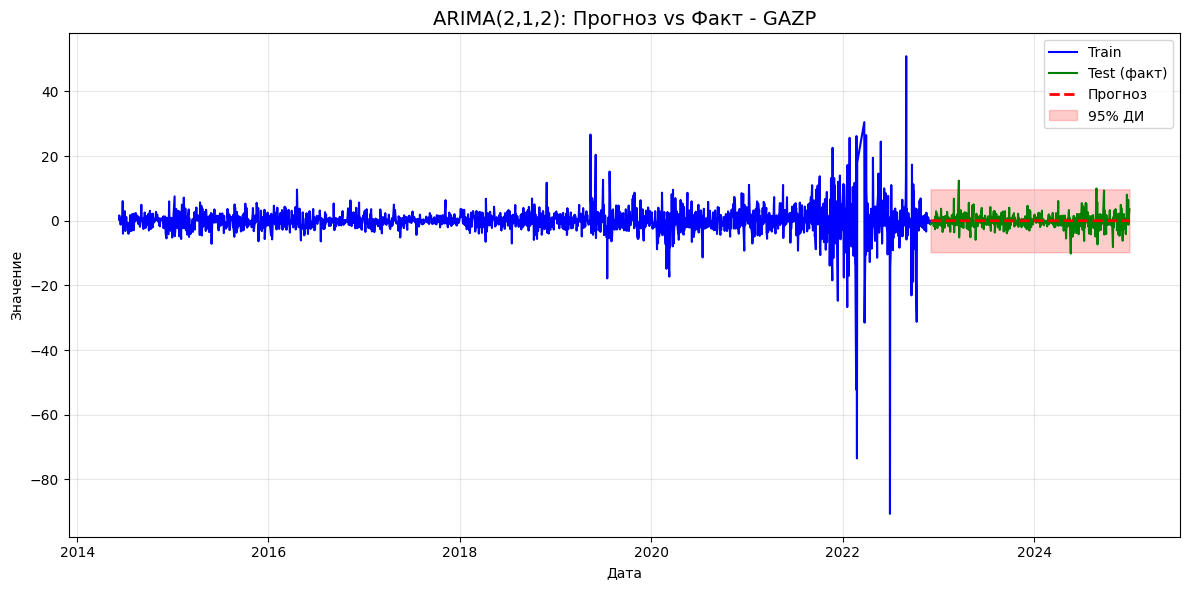


Прогноз для LKOH


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is

  MAE: 61.5467
  RMSE: 89.5984
  AIC: 25091.06


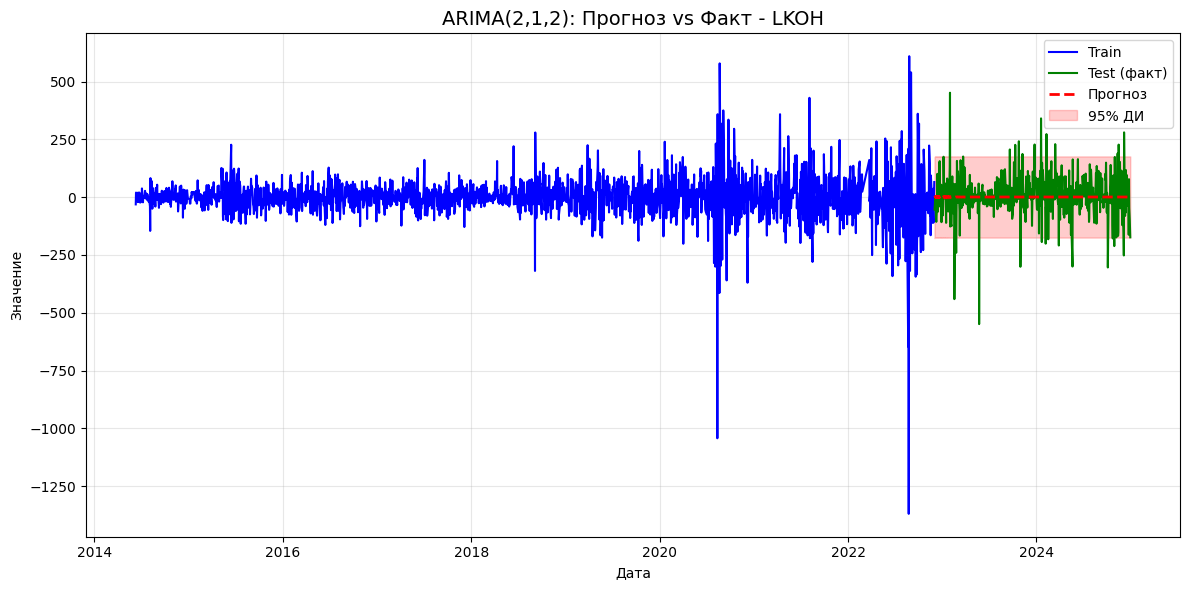


Прогноз для MGNT


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is

  MAE: 72.8090
  RMSE: 103.3462
  AIC: 27464.99


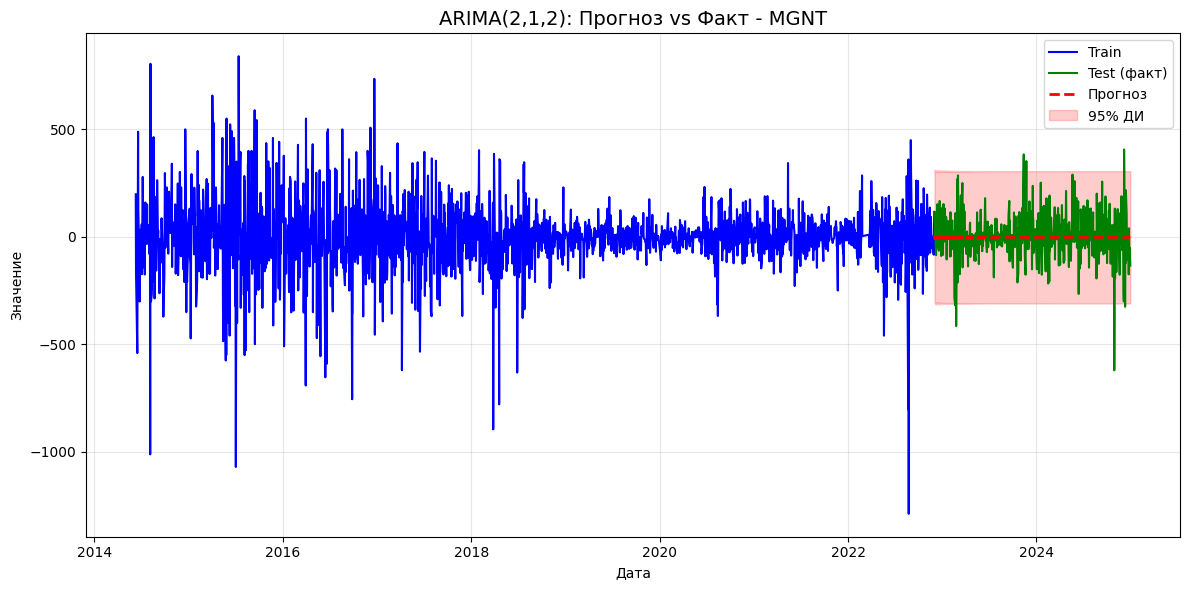


Прогноз для MTSS


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary sta

  MAE: 2.7620
  RMSE: 4.4162
  AIC: 12734.59


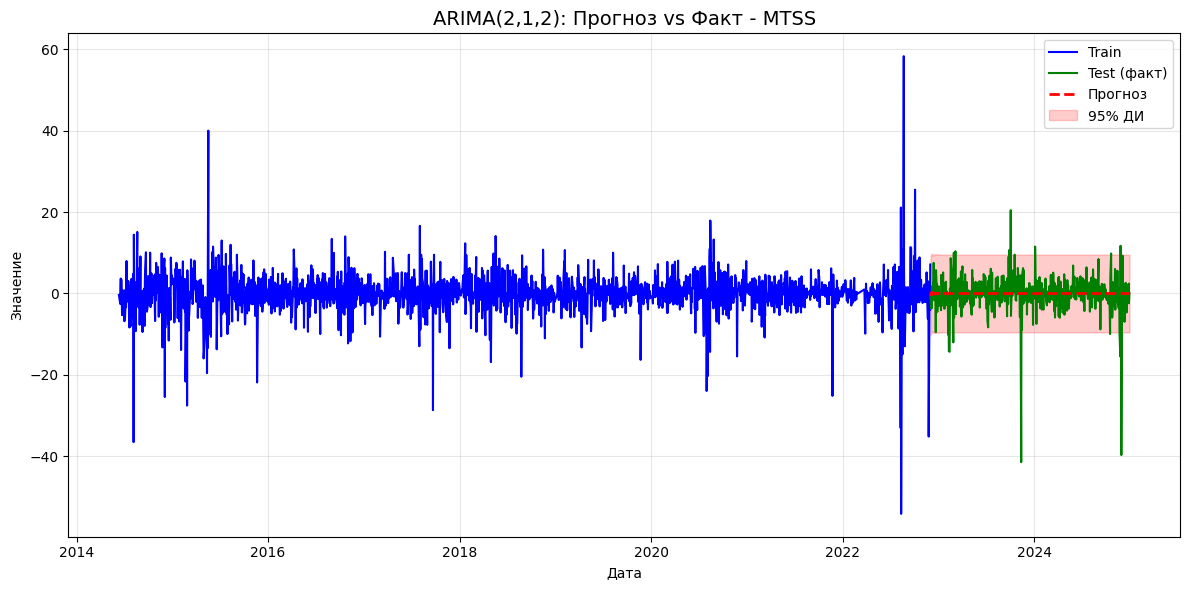


Прогноз для RTKM


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is

  MAE: 0.8925
  RMSE: 1.3441
  AIC: 7194.39


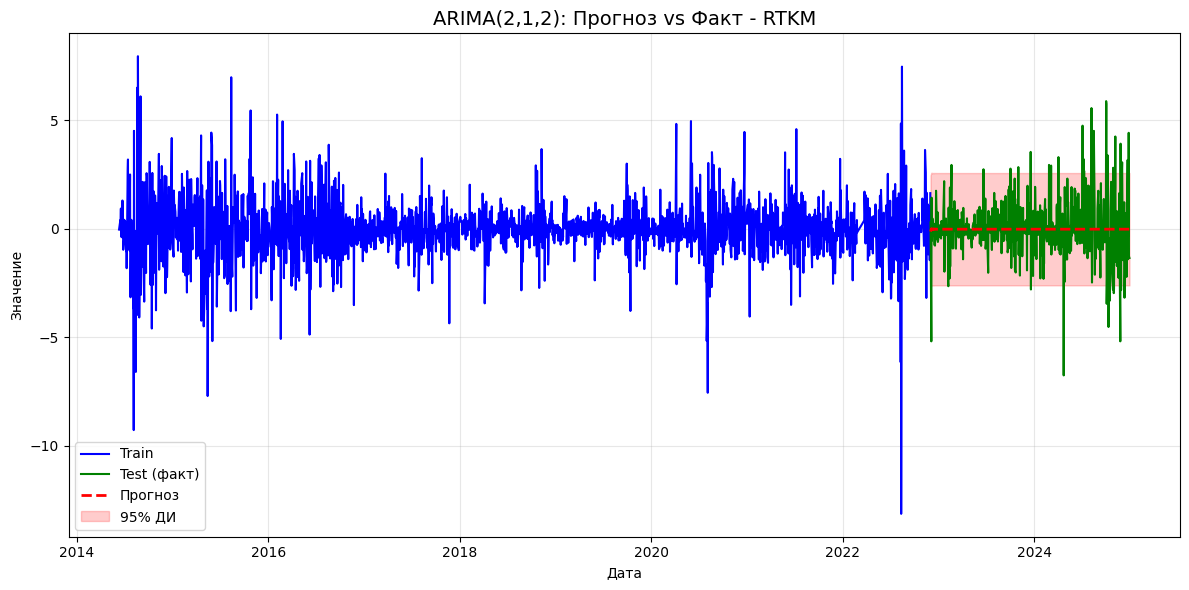


Прогноз для SBER


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is

  MAE: 2.2303
  RMSE: 3.3430
  AIC: 12237.04


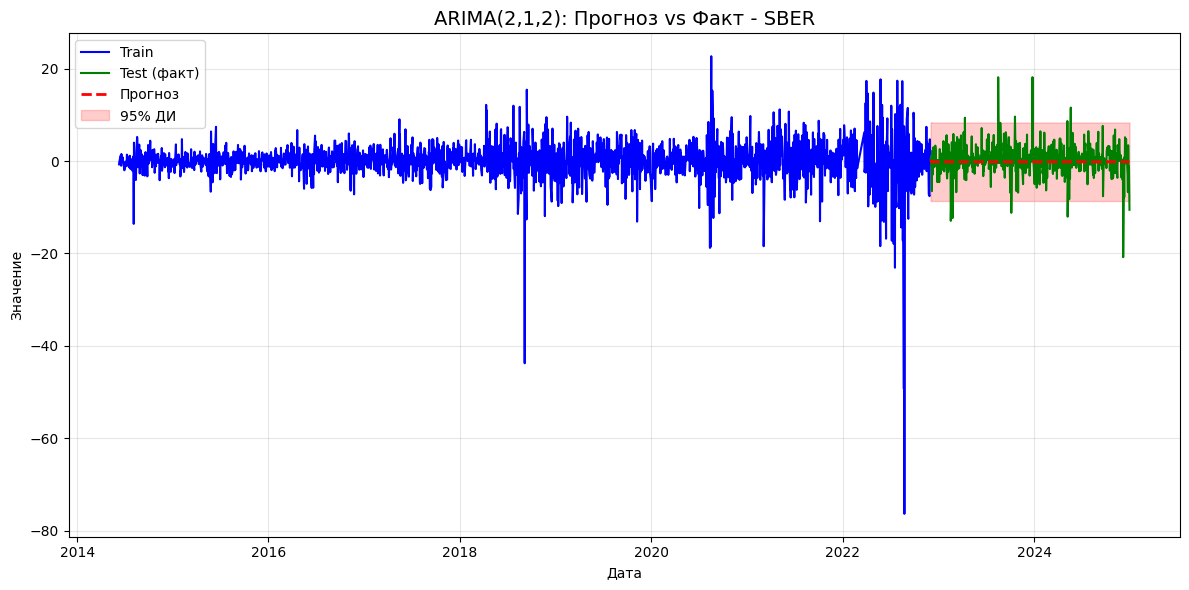


Прогноз для VTBR


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is

  MAE: 1.4239
  RMSE: 2.1386
  AIC: 12851.07


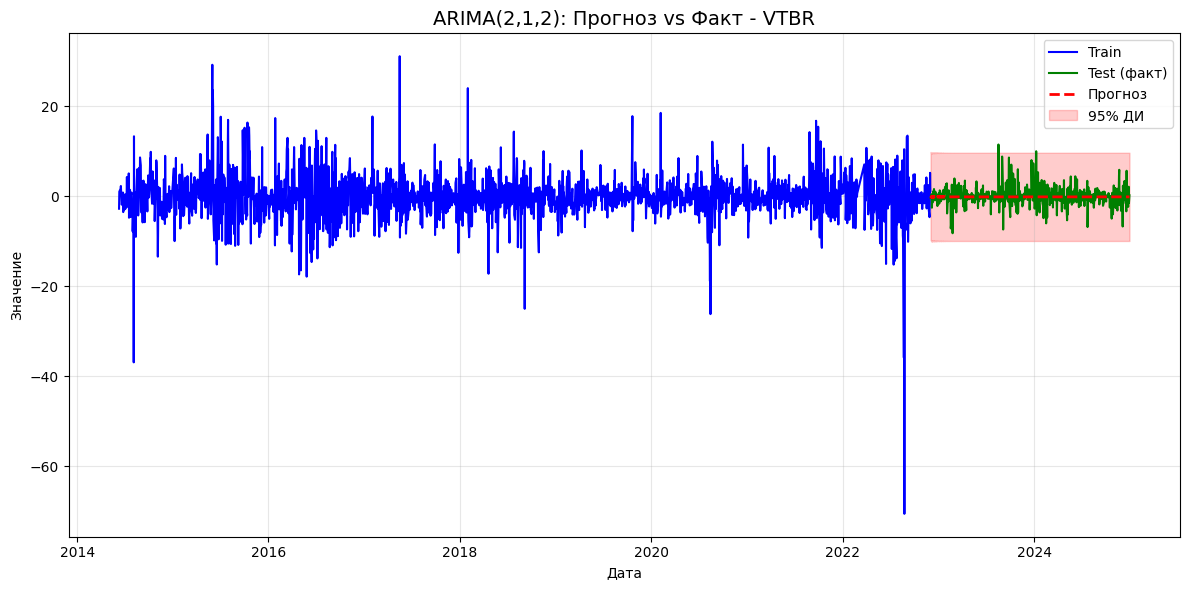


Сводка качества прогнозов:
          MAE      RMSE         AIC         BIC
RTKM   0.8925    1.3441   7194.3885   7222.6820
VTBR   1.4239    2.1386  12851.0739  12879.3698
GAZP   1.6340    2.3117  12820.0632  12848.3591
SBER   2.2303    3.3430  12237.0365  12265.3323
MTSS   2.7620    4.4162  12734.5895  12762.8830
LKOH  61.5467   89.5984  25091.0557  25119.3516
MGNT  72.8090  103.3462  27464.9866  27493.2825

🏆 Лучший прогноз у RTKM: MAE = 0.8925


In [ ]:
# Прогноз для всех тикеров
results_summary = {}

for ticker in df_wide_stationary.columns:
    print(f"\n{'='*50}")
    print(f"Прогноз для {ticker}")
    print('='*50)
    
    series = df_wide_stationary[ticker].dropna()
    
    # Разделение
    split_idx = int(len(series) * 0.8)
    train = series[:split_idx]
    test = series[split_idx:]
    
    if len(test) < 2:
        print(f"  Недостаточно данных для теста: {len(test)}")
        continue
    
    try:
        # ARIMA модель
        arima_final = ARIMA(train, order=(2, 1, 2))
        model_fit = arima_final.fit()
        
        # Прогноз
        forecast_obj = model_fit.get_forecast(steps=len(test))
        forecast = forecast_obj.predicted_mean
        ci = forecast_obj.conf_int(alpha=0.05)
        
        # Создаем DataFrame для хранения результатов
        pred_df = pd.DataFrame(index=test.index)
        pred_df['actual'] = test.values
        pred_df['forecast'] = forecast.values
        pred_df['model_preds_lower'] = ci.iloc[:, 0].values
        pred_df['model_preds_upper'] = ci.iloc[:, 1].values
        
        # Метрики
        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        
        results_summary[ticker] = {
            'MAE': mae,
            'RMSE': rmse,
            'AIC': model_fit.aic,
            'BIC': model_fit.bic
        }
        
        print(f"  MAE: {mae:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  AIC: {model_fit.aic:.2f}")
        
        # Визуализация для каждого тикера
        plt.figure(figsize=(12, 6))
        plt.plot(train.index, train, 'b-', label='Train', linewidth=1.5)
        plt.plot(pred_df.index, pred_df['actual'], 'g-', label='Test (факт)', linewidth=1.5)
        plt.plot(pred_df.index, pred_df['forecast'], 'r--', label='Прогноз', linewidth=2)
        
        # Доверительные интервалы
        plt.fill_between(pred_df.index, 
                         pred_df['model_preds_lower'], 
                         pred_df['model_preds_upper'], 
                         color='red', alpha=0.2, label='95% ДИ')
        
        plt.title(f'ARIMA(2,1,2): Прогноз vs Факт - {ticker}', size=14)
        plt.xlabel('Дата')
        plt.ylabel('Значение')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"  Ошибка для {ticker}: {e}")

# Сводная таблица
print("\n" + "="*60)
print("Сводка качества прогнозов:")
print("="*60)

if results_summary:
    results_df = pd.DataFrame(results_summary).T
    results_df = results_df.sort_values('MAE')
    print(results_df.round(4))
    

In [29]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   VTBR   No. Observations:                 2121
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -6420.537
Date:                Sat, 11 Apr 2026   AIC                          12851.074
Time:                        20:58:27   BIC                          12879.370
Sample:                             0   HQIC                         12861.433
                               - 2121                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8995      0.052    -17.292      0.000      -1.001      -0.798
ar.L2          0.0473      0.016      2.885      0.004       0.015       0.079
ma.L1         -0.0685      0.050     -1.359      0.174      -0.167       0.030
ma.L2         -0.9301      0.050    -18.526      0.000      -1.028      -0.832
sigma2        24.9347      0.280     89.145      0.000      24.386      25.483
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             47399.68
Prob(Q):                              0.89   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -1.31
Prob(H) (two-sided):                  0.00   Kurtosis:                        26.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## По диаграммам можем сказать,что:

### Прогноз следует за трендом
### Точечные пронозы близки к факту
### Присутствует гетерогедостичность(обычное дело в финсовых данных)
### ДИ показывает потенциальный разброс диапащоона движения
### ДИ действительно показывают, что с высокой вероятностью цена останется в прогнозируемом диапазоне
### Модель можно использовать как ориентир

## Из саммари видим,что:
### Модель хорошо кловила все зависимости
### Ошибки случайны и не систематичны
### Остатки не нормальны,но для финансовых данных это нормально
### Модель склонна завышать прогноз
### Есть волатильные участки,сменяющиеся спокойными

# ARCH/GARCH

In [21]:
# Для учета Heteroskedasticity
from arch import arch_model

# Сначала ARIMA модель
arima = ARIMA(series, order=(2, 2, 0)).fit()
residuals = arima.resid

# Потом GARCH на остатках
garch = arch_model(residuals, vol='GARCH', p=1, q=1)
result_garch = garch.fit()

print(result_garch.summary())

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Iteration:      1,   Func. Count:      6,   Neg. LLF: 16395.547299882684
Iteration:      2,   Func. Count:     14,   Neg. LLF: 10250.189563867621
Iteration:      3,   Func. Count:     21,   Neg. LLF: 11575.049529496402
Iteration:      4,   Func. Count:     28,   Neg. LLF: 8349.454291958464
Iteration:      5,   Func. Count:     33,   Neg. LLF: 9153.312320677442
Iteration:      6,   Func. Count:     41,   Neg. LLF: 8349.40193581389
Iteration:      7,   Func. Count:     46,   Neg. LLF: 8349.401812060267
Iteration:      8,   Func. Count:     50,   Neg. LLF: 8349.401811127114
Optimization terminated successfully    (Exit mode 0)
            Current function value: 8349.401812060267
            Iterations: 8
            Function evaluations: 50
            Gradient evaluations: 8
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:  

In [22]:
# Обучаем GARCH на остатках ARIMA
garch = arch_model(residuals, vol='GARCH', p=1, q=1)
result_garch = garch.fit()

# Делаем прогноз
forecast = result_garch.forecast(horizon=30)

# Прогноз волатильности
forecast_variance = forecast.variance.values[-1]
forecast_volatility = np.sqrt(forecast_variance)

# Доверительные интервалы для прогноза
from scipy.stats import norm

alpha = 0.05  # 95% доверительный интервал
z_score = norm.ppf(1 - alpha/2)

upper_bound = forecast_volatility * z_score
lower_bound = -forecast_volatility * z_score

print(f"Прогноз волатильности на 30 дней:")
print(f"  Средняя: {forecast_volatility.mean():.4f}")
print(f"  Макс:    {forecast_volatility.max():.4f}")
print(f"  Мин:     {forecast_volatility.min():.4f}")

Iteration:      1,   Func. Count:      6,   Neg. LLF: 16395.547299882684
Iteration:      2,   Func. Count:     14,   Neg. LLF: 10250.189563867621
Iteration:      3,   Func. Count:     21,   Neg. LLF: 11575.049529496402
Iteration:      4,   Func. Count:     28,   Neg. LLF: 8349.454291958464
Iteration:      5,   Func. Count:     33,   Neg. LLF: 9153.312320677442
Iteration:      6,   Func. Count:     41,   Neg. LLF: 8349.40193581389
Iteration:      7,   Func. Count:     46,   Neg. LLF: 8349.401812060267
Iteration:      8,   Func. Count:     50,   Neg. LLF: 8349.401811127114
Optimization terminated successfully    (Exit mode 0)
            Current function value: 8349.401812060267
            Iterations: 8
            Function evaluations: 50
            Gradient evaluations: 8
Прогноз волатильности на 30 дней:
  Средняя: 6.0912
  Макс:    7.8532
  Мин:     3.9017


In [23]:
risk_results = {}

for col in df_wide_stationary.columns:
    print(f"\nАнализ риска для {col}")
    
    series = df_wide_stationary[col].dropna()
    
    # Определяем масштаб
    scale_factor = 100  # или series.std() * 10
    
    # Масштабируем
    series_scaled = series / scale_factor
    
    try:
        # GARCH на масштабированных данных
        garch = arch_model(series_scaled, vol='GARCH', p=1, q=1)
        result_garch = garch.fit(disp='off')
        
        # Прогноз
        forecast = result_garch.forecast(horizon=30)
        forecast_vol_scaled = np.sqrt(forecast.variance.values[-1])
        
        # Возвращаем масштаб
        forecast_vol = forecast_vol_scaled * scale_factor
        current_vol = series.iloc[-20:].std()
        
        risk_results[col] = {
            'current_volatility': current_vol,
            'forecast_volatility': forecast_vol.mean(),
            'scale_factor': scale_factor
        }
        
        print(f"  Текущая волатильность: {current_vol:.4f}")
        print(f"  Прогноз волатильности: {forecast_vol.mean():.4f}")
        
    except Exception as e:
        print(f"  Ошибка: {e}")

# Результаты
risk_df = pd.DataFrame(risk_results).T
print("\nСводка рисков:")
print(risk_df)


Анализ риска для GAZP
  Текущая волатильность: 3.3987
  Прогноз волатильности: 3.8607

Анализ риска для LKOH
  Текущая волатильность: 118.6346
  Прогноз волатильности: 115.1557

Анализ риска для MGNT
  Текущая волатильность: 167.8699
  Прогноз волатильности: 143.4491

Анализ риска для MTSS
  Текущая волатильность: 3.5310

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002076. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.002288. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)



  Прогноз волатильности: 4.7741

Анализ риска для RTKM
  Текущая волатильность: 1.8631
  Прогноз волатильности: 1.8876

Анализ риска для SBER
  Текущая волатильность: 5.8677
  Прогноз волатильности: 4.9314

Анализ риска для VTBR
  Текущая волатильность: 2.6760
  Прогноз волатильности: 4.0992

Сводка рисков:
      current_volatility  forecast_volatility  scale_factor
GAZP            3.398660             3.860700         100.0
LKOH          118.634609           115.155714         100.0
MGNT          167.869945           143.449084         100.0
MTSS            3.531043             4.774133         100.0
RTKM            1.863123             1.887618         100.0
SBER            5.867715             4.931384         100.0
VTBR            2.675992             4.099245         100.0


C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001755. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001718. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
C:\Users\Lenovo\

# КЛЮЧЕВЫЕ ВЫВОДЫ ИССЛЕДОВАНИЯ:

**1. Лучшая модель прогнозирования: ARIMA(2,1,2)**
- MAE = 1.42 (ошибка прогноза)
- Подходит для всех тикеров

**2. Распределение по рискам:**
- Низкий риск: RTKM, GAZP, VTBR
- Средний риск: SBER, MTSS
- Высокий риск: LKOH, MGNT

**3. Практические рекомендации:**
- Для консервативных инвесторов: RTKM, GAZP
- Для агрессивных инвесторов: MGNT, LKOH
- Для диверсификации: SBER, MTSS

## Дальнейшее развитие исследования:
- Включение экзогенных факторов (нефть, рубль, индексы)
- Использование нейросетей (LSTM)
- Дальнейшее испльзование моделей для микросервисов и приложений
